In [1]:
%matplotlib inline
import pandas as pd
from pandas import DataFrame, Series
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as colors
from matplotlib.legend_handler import HandlerLine2D, HandlerTuple
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import scikit_posthocs as sp
import sys

from mpl_toolkits.mplot3d import axes3d

In [2]:
AllName="dataG.pkl"
ResizesName="dataM.pkl"
ItersName="dataL"
NameExtension=".pkl"
repet = 20 #CAMBIAR EL NUMERO SEGUN NUMERO DE EJECUCIONES POR CONFIG

significance_value = 0.05
processes = [20,40,80,160] #N
#processes = [112,224,448,896,1792,2688,3584] #N
#processes = [32,64,128,192,256] #S
#processes = [20,52,104,156,208,260,312,364,416] #Hetero

positions = [321, 322, 323, 324, 325]
positions_small = [221, 222, 223, 224]

#                       WORST        BEST
labels_dist = ['null', 'SpreadFit', 'CompactFit']
                  #0          #1                #2                        #3
labelsMethods = ['Baseline', 'Baseline single','Baseline - Asynchronous','Baseline single - Asynchronous',
                 'Merge','Merge single','Merge - Asynchronous','Merge single - Asynchronous']
                  #4      #5             #6                     #7
    
colors_m = ['green','darkgreen','red','darkred','mediumseagreen','seagreen','palegreen','springgreen','indianred','firebrick','darkgoldenrod','saddlebrown']
linestyle_m = ['-', '--', '-.', ':']
markers_m = ['.','v','s','p', 'h','d','X','P','^']

OrMult_patch = mpatches.Patch(hatch='', facecolor='green', label='Baseline')
OrSing_patch = mpatches.Patch(hatch='', facecolor='springgreen', label='Baseline single')
OrPthMult_patch = mpatches.Patch(hatch='//', facecolor='blue', label='Baseline - Asyncrhonous')
OrPthSing_patch = mpatches.Patch(hatch='\\', facecolor='darkblue', label='Baseline single - Asyncrhonous')
MergeMult_patch = mpatches.Patch(hatch='||', facecolor='red', label='Merge')
MergeSing_patch = mpatches.Patch(hatch='...', facecolor='darkred', label='Merge single')
MergePthMult_patch = mpatches.Patch(hatch='xx', facecolor='yellow', label='Merge - Asyncrhonous')
MergePthSing_patch = mpatches.Patch(hatch='++', facecolor='olive', label='Merge single - Asyncrhonous')

handles_spawn = [OrMult_patch,OrSing_patch,OrPthMult_patch,OrPthSing_patch,MergeMult_patch,MergeSing_patch,MergePthMult_patch,MergePthSing_patch]

In [3]:
dfG = pd.read_pickle( AllName )

dfG['ADR'] = round((dfG['ADR'] / dfG['DR']) * 100,1)
dfG['SDR'] = round((dfG['SDR'] / dfG['DR']) * 100,1)
       
out_group = dfG.groupby(['Groups', 'ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy'])['T_total']
group = dfG.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'Groups'])['T_total']

grouped_aggG = group.agg(['median'])
grouped_aggG.rename(columns={'median':'T_total'}, inplace=True) 

out_grouped_G = out_group.agg(['median'])
out_grouped_G.rename(columns={'median':'T_total'}, inplace=True) 

In [4]:
dfM = pd.read_pickle( ResizesName )

dfM['ADR'] = round((dfM['ADR'] / dfM['DR']) * 100,1)
dfM['SDR'] = round((dfM['SDR'] / dfM['DR']) * 100,1)
dfM['T_Redistribution'] = dfM['T_SR'] + dfM['T_AR']
dfM.loc[dfM['T_Malleability']==0,'T_Malleability'] = dfM['T_spawn'] + dfM['T_Redistribution']

#dfM = dfM[dfM.NP<dfM.NC]
       
out_group = dfM.groupby(['NP','NC','ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy'])['T_Malleability','T_Redistribution','T_spawn','T_SR','T_AR', 'T_US', 'Asynch_Iters']
group = dfM.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy' ,'NP','NC'])['T_Malleability','T_Redistribution','T_spawn','T_SR','T_AR', 'T_US', 'Asynch_Iters']

grouped_aggM = group.agg(['median'])
grouped_aggM.columns = grouped_aggM.columns.get_level_values(0)

out_grouped_M = out_group.agg(['median'])
out_grouped_M.columns = out_grouped_M.columns.get_level_values(0)

/tmp/ipykernel_482287/927069303.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  out_group = dfM.groupby(['NP','NC','ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy'])['T_Malleability','T_Redistribution','T_spawn','T_SR','T_AR', 'T_US', 'Asynch_Iters']
/tmp/ipykernel_482287/927069303.py:11: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  group = dfM.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy' ,'NP','NC'])['T_Malleability','T_Redistribution','T_spawn','T_SR','T_AR', 'T_US', 'Asynch_Iters']


In [5]:
grouped_aggLAsynch = pd.DataFrame()
grouped_aggLSynch = pd.DataFrame()
grouped_aggLDyn = pd.DataFrame()
grouped_aggLNDyn = pd.DataFrame()

for i in range(2):
    aux_name = ItersName + str(i) + NameExtension
    dfL = pd.read_pickle( aux_name )

    #Fixme comprobar si hay iters asincronas antes de esto
    aux_df = dfL[(dfL.Asynch_Iters == True)]
    #aux_df['ADR'] = round((aux_df['ADR'] / aux_df['DR']) * 100,1)
    dfL.loc[(dfL.Asynch_Iters == True),'ADR'] = round((aux_df['ADR'] / aux_df['DR']) * 100,1)
    #dfL['SDR'] = round((dfL['SDR'] / dfL['DR']) * 100,1)
    dfL.loc[(dfL.Asynch_Iters == True),'SDR'] = round((aux_df['SDR'] / aux_df['DR']) * 100,1)
    dfL['ADR'].fillna(-1, inplace=True)
    dfL['SDR'].fillna(-1, inplace=True)
    dfL['DR'].fillna(-1, inplace=True)
       
    aux_df = dfL[(dfL.Asynch_Iters == True)]
    group = aux_df.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','NC'])['T_iter']
    grouped_aux = group.agg(['median','count'])
    grouped_aux.columns = grouped_aux.columns.get_level_values(0)
    grouped_aux.rename(columns={'median':'T_iter'}, inplace=True) 
    group = aux_df.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','NC'])['T_stages']
    aux_column = group.apply(list).apply(lambda x: np.median(x,0))
    grouped_aux['T_stages'] = aux_column
    if grouped_aggLAsynch.empty:
        grouped_aggLAsynch = grouped_aux
    else:
        grouped_aggLAsynch = pd.concat([grouped_aggLAsynch, grouped_aux], ignore_index=False, sort=True).sort_index()

    aux_df = dfL[(dfL.Asynch_Iters == False)]
    group = aux_df.groupby('NP')['T_iter']
    grouped_aux = group.agg(['median'])
    grouped_aux.rename(columns={'median':'T_iter'}, inplace=True)
    group = aux_df.groupby(['NP'])['T_stages']
    aux_column = group.apply(list).apply(lambda x: np.median(x,0))
    grouped_aux['T_stages'] = aux_column
    if grouped_aggLSynch.empty:
        grouped_aggLSynch = grouped_aux
    else:
        grouped_aggLSynch = pd.concat([grouped_aggLSynch, grouped_aux], ignore_index=False, sort=True).sort_index()

    aux_df2 = aux_df[(aux_df.Is_Dynamic == True)]
    group = aux_df2.groupby(['ADR', 'Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','N_Parents'])['T_iter']
    grouped_aux = group.agg(['median'])
    grouped_aux.rename(columns={'median':'T_iter'}, inplace=True)
    group = aux_df2.groupby(['ADR', 'Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','N_Parents'])['T_stages']
    aux_column = group.apply(list).apply(lambda x: np.median(x,0))
    grouped_aux['T_stages'] = aux_column
    if grouped_aggLDyn.empty:
        grouped_aggLDyn = grouped_aux
    else:
        grouped_aggLDyn = pd.concat([grouped_aggLDyn, grouped_aux], ignore_index=False, sort=True).sort_index()

    aux_df2 = aux_df[(aux_df.Is_Dynamic == False)]
    group = aux_df2.groupby('NP')['T_iter']
    grouped_aux = group.agg(['median'])
    grouped_aux.rename(columns={'median':'T_iter'}, inplace=True)
    group = aux_df2.groupby(['NP'])['T_stages']
    aux_column = group.apply(list).apply(lambda x: np.median(x,0))
    grouped_aux['T_stages'] = aux_column
    if grouped_aggLNDyn.empty:
        grouped_aggLNDyn = grouped_aux
    else:
        grouped_aggLNDyn = pd.concat([grouped_aggLNDyn, grouped_aux], ignore_index=False, sort=True).sort_index()
dfL = None

group = grouped_aggLAsynch.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','NC'])
grouped_aux = group.agg(['mean'])
grouped_aux.columns = grouped_aux.columns.get_level_values(0)
grouped_aux['T_sum'] = grouped_aux['count'] * grouped_aux['T_iter']
grouped_aggLAsynch = grouped_aux

group = grouped_aggLSynch.groupby('NP')
grouped_aux = group.agg(['mean'])
grouped_aux.columns = grouped_aux.columns.get_level_values(0)
grouped_aggLSynch = grouped_aux

group = grouped_aggLDyn.groupby(['ADR', 'Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','N_Parents'])
grouped_aux = group.agg(['mean'])
grouped_aux.columns = grouped_aux.columns.get_level_values(0)
grouped_aggLDyn = grouped_aux

group = grouped_aggLNDyn.groupby('NP')
grouped_aux = group.agg(['mean'])
grouped_aux.columns = grouped_aux.columns.get_level_values(0)
grouped_aggLNDyn = grouped_aux

In [6]:
import dask.dataframe as dd
grouped_aggLAsynch = pd.DataFrame()
group_A = pd.DataFrame()
group_A_col = None

for i in range(3):
    aux_name = ItersName + str(i) + NameExtension
    dfL = pd.read_pickle( aux_name )

    #Fixme comprobar si hay iters asincronas antes de esto
    aux_df = dfL[(dfL.Asynch_Iters == True)]
    dfL.loc[(dfL.Asynch_Iters == True),'ADR'] = round((aux_df['ADR'] / aux_df['DR']) * 100,1)
    dfL.loc[(dfL.Asynch_Iters == True),'SDR'] = round((aux_df['SDR'] / aux_df['DR']) * 100,1)
    dfL['ADR'].fillna(-1, inplace=True)
    dfL['SDR'].fillna(-1, inplace=True)
    dfL['DR'].fillna(-1, inplace=True)
    
    dfL = dd.from_pandas(dfL, npartitions=3)
       
    aux_df = dfL[(dfL.Asynch_Iters == True)]
    group2 = aux_df.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','NC'])['T_stages']
    if len(group_A.columns) > 0:
        group_A = aux_df
    else:
        group_A = dd.concat([group_A, aux_df], ignore_index=False, sort=True)
   #     group_A = group
   #     group_A_col = group2
   # else:
   #     print(group+group_A)
   #     group_A = pd.concat([group_A, group], ignore_index=False, sort=True).sort_index()
   #     group_A_col = pd.concat([group_A_col, group2], ignore_index=False, sort=True).sort_index()
#dfL = None

custom_mean = dd.Aggregation(
    name='custom_mean',
    chunk=lambda s: np.sum(list(s), axis=0),
    agg=lambda count: count.sum(),
    finalize=lambda count: count,
)  

#custom_mean = dd.Aggregation(
#    name='custom_mean',
#    chunk=lambda s: (s.count(), np.sum(list(s), axis=0)),
#    agg=lambda count, sum: (count.sum(), np.sum(sum, axis=0)),
#    finalize=lambda count, sum: sum / count,
#)  

group  = group_A.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','NC'])['T_iter']
group2 = group_A.groupby(['ADR','Spawn_Method','Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy', 'NP','NC'])['T_stages']
grouped_aux = group.agg(['median','count'], shuffle='tasks').compute()
grouped_aux.columns = grouped_aux.columns.get_level_values(0)
grouped_aux.rename(columns={'median':'T_iter'}, inplace=True)

def expand_tuple(df, col):
    return pd.concat([df, df[col].apply(pd.Series)], axis=1).rename(columns=lambda x: col + '_' + str(x) if isinstance(x, int) else x)

#df_expanded = group_A.map_partitions(expand_tuple, col='T_stages')

result = group_A['T_stages'].apply(pd.Series)
print(result)

#aggregations = {f'T_stages_{i}': 'mean' for i in range(4)}  # Aquí asumimos que las tuplas tienen 4 elementos

# Agrupar por la columna B y calcular la media de cada componente
#result = df_expanded.groupby('B').agg(aggregations)


#grouped_aux['T_stages'] = aux_column
#grouped_aux.columns = grouped_aux.columns.get_level_values(0)
#grouped_aux['T_sum'] = grouped_aux['count'] * grouped_aux['T_iter']
#grouped_aggLAsynch = grouped_aux
#print(grouped_aux)

FileNotFoundError: [Errno 2] No such file or directory: 'dataL2.pkl'

In [7]:
from bt_scheme import PartialSolution, BacktrackingSolver
def elegirConf(parameters):
    class StatePS(PartialSolution):
        def __init__(self, config):
            self.config= config
            self.n= len(config) #Indica el valor a añadir

        def is_solution(self):
            return self.n == len(parameters)

        def get_solution(self):
            return tuple(self.config)

        def successors(self):
            array = parameters[self.n]
            for parameter_value in array: #Test all values of the next parameter
                self.config.append(parameter_value)
                yield StatePS(self.config)
                self.config.pop()

    initialPs= StatePS([])
    return BacktrackingSolver().solve(initialPs)


def obtenerConfs(parameters):
    soluciones=[]
    for solucion in elegirConf(parameters):
        soluciones.append(solucion)
    return soluciones

def modifyToGlobal(parameters, len_parameters, configuration):
    usable_configuration = []
    for i in range(len(parameters)):
        if len_parameters[i] > 1:
            aux = (parameters[i][0], configuration[i])
        else:
            aux = (configuration[i])
        usable_configuration.append(aux)
        
    return usable_configuration

def modifyToLocalDynamic(parameters, len_parameters, configuration):
    usable_configuration = []
    for i in range(len(parameters)):
        if len_parameters[i] > 1:
            aux = (configuration[i], -1)
        else:
            aux = (-1)
        usable_configuration.append(aux)
        
    return tuple(usable_configuration)

def CheckConfExists(configuration, dataSet, type_conf='global'):
    exists = False
    config = list(configuration)
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                
                if type_conf == 'global':
                    config.append((np_aux, ns_aux))
                elif type_conf == 'malleability':
                    config.append(np_aux)
                    config.append(ns_aux)
                elif type_conf == 'local':
                    config.append(np_aux)
                    
                if tuple(config) in dataSet.index:     
                    exists = True # FIXME Return here true?
                config.pop()
                
                if type_conf == 'malleability':
                    config.pop()
    return exists

In [14]:
adr = [0,100]
sp_method = [0,1]
rd_method = [0,2,3]
sp_strat  = [0]
rd_strat  = [0,1,3]
parameters = [adr, sp_method, rd_method, sp_strat, rd_strat]
parameters_names = ['ADR', 'Spawn_Method', 'Redistribution_Method', 'Spawn_Strategy', 'Redistribution_Strategy']
len_parameters = [1,2,2,2,2]
configurations_aux = obtenerConfs(parameters)
configurations = []
configurations_local_dynamic = set()
configurations_local = set()
configurations_simple = []
for checked_conf in configurations_aux:
    aux_conf = modifyToGlobal(parameters, len_parameters, checked_conf)
    if CheckConfExists(aux_conf, grouped_aggG):
        configurations.append(aux_conf)

    if CheckConfExists(checked_conf, grouped_aggM, 'malleability'):
        configurations_simple.append(list(checked_conf))
        
    aux_conf = modifyToLocalDynamic(parameters, len_parameters, checked_conf)
    if CheckConfExists(aux_conf, grouped_aggLDyn, 'local'):
        configurations_local_dynamic.add(aux_conf)

configurations_local_dynamic = list(configurations_local_dynamic)
for index in range(len(configurations_local_dynamic)):
    configurations_local_dynamic[index] = list(configurations_local_dynamic[index])    
print(configurations_simple)
print(configurations_local_dynamic)
print(configurations)
print(len(configurations))

[[0, 1, 0, 0, 0], [0, 1, 2, 0, 0], [0, 1, 3, 0, 0], [100, 1, 0, 0, 0], [100, 1, 0, 0, 1], [100, 1, 0, 0, 3], [100, 1, 2, 0, 1], [100, 1, 2, 0, 3], [100, 1, 3, 0, 1], [100, 1, 3, 0, 3]]
[[-1, (1, -1), (3, -1), (0, -1), (0, -1)], [-1, (1, -1), (0, -1), (0, -1), (0, -1)], [-1, (1, -1), (0, -1), (0, -1), (1, -1)], [-1, (1, -1), (2, -1), (0, -1), (0, -1)], [-1, (1, -1), (3, -1), (0, -1), (1, -1)], [-1, (1, -1), (3, -1), (0, -1), (3, -1)], [-1, (1, -1), (2, -1), (0, -1), (1, -1)], [-1, (1, -1), (0, -1), (0, -1), (3, -1)], [-1, (1, -1), (2, -1), (0, -1), (3, -1)]]
[[0, (0, 1), (0, 0), (0, 0), (0, 0)], [0, (0, 1), (0, 2), (0, 0), (0, 0)], [0, (0, 1), (0, 3), (0, 0), (0, 0)], [100, (0, 1), (0, 0), (0, 0), (0, 0)], [100, (0, 1), (0, 0), (0, 0), (0, 1)], [100, (0, 1), (0, 0), (0, 0), (0, 3)], [100, (0, 1), (0, 2), (0, 0), (0, 1)], [100, (0, 1), (0, 2), (0, 0), (0, 3)], [100, (0, 1), (0, 3), (0, 0), (0, 1)], [100, (0, 1), (0, 3), (0, 0), (0, 3)]]
10


In [9]:
#ALPHA COMPUTATION
def compute_alpha(config_a, config_b):
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                config_a.append(np_aux)
                config_a.append(ns_aux)
                config_b.append(np_aux)
                config_b.append(ns_aux)
                grouped_aggM.loc[tuple(config_b),'Alpha'] = grouped_aggM.loc[tuple(config_b),'T_Malleability'] / grouped_aggM.loc[tuple(config_a),'T_Malleability']
                #grouped_aggM.loc[tuple(config_b),'Alpha'] = grouped_aggM.loc[tuple(config_b),'T_Redistribution'] / grouped_aggM.loc[tuple(config_a),'T_Redistribution']
                config_a.pop()
                config_a.pop()
                config_b.pop()
                config_b.pop()
                
                
                config_a.insert(0,ns_aux)
                config_a.insert(0,np_aux)
                config_b.insert(0,ns_aux)
                config_b.insert(0,np_aux)
                out_grouped_M.loc[tuple(config_b),'Alpha'] = out_grouped_M.loc[tuple(config_b),'T_Malleability'] / out_grouped_M.loc[tuple(config_a),'T_Malleability']
                #out_grouped_M.loc[tuple(config_b),'Alpha'] = out_grouped_M.loc[tuple(config_b),'T_Redistribution'] / out_grouped_M.loc[tuple(config_a),'T_Redistribution']
                
                config_a.pop(0)
                config_a.pop(0)
                config_b.pop(0)
                config_b.pop(0)

#FIXME: No considera Sp_St==1 (Spawn con threads) como algo para el alpha - Puede dar problemas para Sp_St != 0
if not ('Alpha' in grouped_aggM.columns):
    for config_a in configurations_simple:
        for config_b in configurations_simple:
            if config_a[1:3] == config_b[1:3] and config_a[0] == 0 and config_b[0] != 0:
                #print(config_a)
                #print(config_b)
                compute_alpha(config_a, config_b)
else:
    print("ALPHA already exists")

In [10]:
#OMEGA COMPUTATION
def compute_omega(config):
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                if len(config) > len(parameters):
                    config.pop()
                    config.pop()
                config.append(np_aux)
                config.append(ns_aux)
                
                if tuple(config) in grouped_aggLAsynch.index:
                    value = grouped_aggLAsynch.at[tuple(config),'T_iter'] / grouped_aggLSynch.at[np_aux,'T_iter']
                    grouped_aggLAsynch.at[tuple(config),'Omega'] = value
                
                    #grouped_aggLAsynch.at[tuple(config),'Omega'] = grouped_aggLAsynch.at[tuple(config),'T_iter'] / grouped_aggLSynch.at[np_aux,'T_iter']
                    value = grouped_aggLAsynch.at[tuple(config),'T_stages'] / grouped_aggLSynch.at[np_aux,'T_stages']
                    grouped_aggLAsynch.at[tuple(config),'Omega_Stages'] = value.astype(object)

if not ('Omega' in grouped_aggLAsynch.columns):
    grouped_aggLAsynch['Omega'] = 1.0
    grouped_aggLAsynch['Omega_Stages'] = None
    for config in configurations:
        if config[0] != 0:
            compute_omega(config)
else:
    print("OMEGA already exists")

In [11]:
#Dynamic Coherence COMPUTATION
def compute_dyn_coherency(config):
    for np_aux in processes:
        for n_parents_aux in processes:
            if np_aux != n_parents_aux:
                if len(config) > len(parameters):
                    config.pop()
                    config.pop()
                config.append(np_aux)
                config.append(n_parents_aux)
                
                if tuple(config) in grouped_aggLDyn.index:
                    value = grouped_aggLDyn.at[tuple(config),'T_iter'] / grouped_aggLNDyn.at[np_aux,'T_iter']
                    grouped_aggLDyn.at[tuple(config),'Dyn_Coherency'] = value
                    value = grouped_aggLDyn.at[tuple(config),'T_stages'] / grouped_aggLNDyn.at[np_aux,'T_stages']
                    grouped_aggLDyn.at[tuple(config),'Dyn_Coherency_Stages'] = value.astype(object)

if not ('Dyn_Coherency' in grouped_aggLDyn.columns):
    grouped_aggLDyn['Dyn_Coherency'] = 1.0
    grouped_aggLDyn['Dyn_Coherency_Stages'] = None
    for config in configurations_local_dynamic:
        compute_dyn_coherency(config)
else:
    print("Dyn_Coherency already exists")

In [12]:
#Malleability Coherence COMPUTATION
#FIXME: Does not consider USER FUNCTION TIME
test=dfM[(dfM.Asynch_Iters > 0)]
coherence_boundary = 1.01 # Allows a 1% error
total_aux = 0
show_all = False

# Coherence of synchronous inner times + asynchronous iterations
for index in range(len(test)):
    time_malleability_aux = test["T_Malleability"].values[index]
    
    # Get sum time of async iters
    total_asynch_iters = int(test["Asynch_Iters"].values[index])
    asynch_iters = test["T_iter"].values[index][-total_asynch_iters:]
    time_iters_aux = np.sum(asynch_iters)
    
    time_synch_aux = test["T_SR"].values[index]
    time_spawn_aux = test["T_spawn"].values[index]
    is_synch_spawn = (test["Spawn_Strategy"].values[index] == 0)
    
    expected_time = time_iters_aux + time_spawn_aux * is_synch_spawn + time_synch_aux
    time_malleability_max = time_malleability_aux * coherence_boundary
    
    if time_malleability_max < expected_time:
        total_aux += 1
        if show_all:
            print(test.iloc[index])
            print(asynch_iters)
            print(time_iters_aux)
            print(time_malleability_max)
            print("")
if total_aux > 0:
    print("Coherence fails for inner synchronous times + asynchornous iterations in " + str(total_aux) + " cases")

In [13]:
#Malleability Coherence COMPUTATION
test=dfM[(dfM.Asynch_Iters > 0)]
coherence_boundary = 1.01 # Allows a 1% error
# Coherence of inner times
aux_df = test["T_Malleability"] * coherence_boundary < (test["T_spawn"] + test["T_Redistribution"])
if not test[aux_df].empty:
    print("Coherence fails for inner times of malleability in " + str(len(test[aux_df])) + " cases")
    display(test[aux_df])

In [14]:
pd.set_option('display.max_rows', 10)
display(grouped_aggLAsynch)

T_iter  \
ADR   Spawn_Method Redistribution_Method Spawn_Strategy Redistribution_Strategy NP  NC                
100.0 (0, 1)       (0, 0)                (0, 0)         (0, 0)                  20  40.0   1.621693   
                                                                                    80.0   0.149540   
                                                                                    160.0  0.146664   
                                                                                40  20.0   0.156751   
                                                                                    80.0   0.421860   
...                                                                                             ...   
                   (0, 3)                (0, 0)         (0, 3)                  80  40.0   0.117521   
                                                                                    160.0  0.082744   
                                                                                160 20.0   0.120670   
                                                                                    40.0   0.105694   
                                                                                    80.0   0.087774   

                                                                                                                                    T_stages  \
ADR   Spawn_Method Redistribution_Method Spawn_Strategy Redistribution_Strategy NP  NC                                                         
100.0 (0, 1)       (0, 0)                (0, 0)         (0, 0)                  20  40.0   [0.0713885, 1.5682325000000001, 0.006295999999...   
                                                                                    80.0   [0.071354, 0.004926, 0.006802000000000001, 0.0...   
                                                                                    160.0  [0.071351, 0.0047315, 0.0038335, 0.06556300000...   
                                                                                40  20.0              [0.035676, 0.00022, 3.1e-05, 0.120756]   
                                                                                    80.0   [0.035681000000000004, 0.0048315, 0.0004105, 0...   
...                                                                                                                                      ...   
                   (0, 3)                (0, 0)         (0, 3)                  80  40.0   [0.018731, 0.00147, 6.1000000000000005e-05, 0....   
                                                                                    160.0           [0.018738, 0.0011275, 4.65e-05, 0.06168]   
                                                                                160 20.0            [0.010703, 0.001768, 0.000205, 0.102023]   
                                                                                    40.0           [0.010703, 0.000815, 0.0001215, 0.087035]   
                                                                                    80.0           [0.010704, 0.0013175, 6.25e-05, 0.072023]   

                                                                                           count  \
ADR   Spawn_Method Redistribution_Method Spawn_Strategy Redistribution_Strategy NP  NC             
100.0 (0, 1)       (0, 0)                (0, 0)         (0, 0)                  20  40.0    20.0   
                                                                                    80.0   318.0   
                                                                                    160.0  470.0   
                                                                                40  20.0   403.0   
                                                                                    80.0   116.0   
...                                                                                          ...   
                   (0, 3)                (0, 0)         (0, 3)                  

In [138]:
out_grouped_G.to_excel("resultG.xlsx") 
out_grouped_M.to_excel("resultM.xlsx") 
grouped_aggLAsynch.to_excel("AsynchIters.xlsx")
grouped_aggLSynch.to_excel("SynchIters.xlsx")
grouped_aggLNDyn.to_excel("StaticCoherence.xlsx")
grouped_aggLDyn.to_excel("DynCoherence.xlsx")

In [15]:
def create_group_boundary(rms_boundary, np_aux, ns_aux):
    tc_boundary = 0
    boundaries = None
    if rms_boundary != 0:
        # El porcentaje de tc_boundary se tiene en cuenta para eliminar aquellos
        # tiempos demasiado grandes en su malleability time respecto al más pequeño
        boundaries = get_np_ns_data("T_Malleability", grouped_aggM, configurations_simple, np_aux, ns_aux)
        tc_boundary = min(boundaries)
        tc_boundary = tc_boundary + tc_boundary*rms_boundary
    return tc_boundary, boundaries

# Aquellos grupos que tengán valores por encima del límite no se considerarán
def check_groups_boundaries(dataLists, boundaries, tc_boundary):
    for index in range(len(boundaries)):
        if boundaries[index] > tc_boundary:
            dataLists[index] = float('infinity')

In [16]:
def get_perc_differences(dataLists, boundaries, tc_boundary):
    perc = 1.05
    if boundaries != None: # Si se usa perspectiva de RMS, se desconsideran valores muy altos
        check_groups_boundaries(dataLists, boundaries, tc_boundary) 
    indexes = np.argsort(dataLists)
    
    best = -1
    bestMax = -1
    otherBest=[]
    for index in indexes: # Para cada metodo -- Empezando por el tiempo más bajo en media/mediana
        if best == -1:
            best = index
            bestMax = dataLists[best] * perc
        elif dataLists[index] <= bestMax: # Media/Medianas i < Media/Mediana best
            otherBest.append(index)
                
    otherBest.insert(0,best)
    return otherBest

def get_stat_differences(dataLists, df_Res, boundaries, tc_boundary):
    if boundaries != None: # Si se usa perspectiva de RMS, se desconsideran valores muy altos
        check_groups_boundaries(dataLists, boundaries, tc_boundary) 
    indexes = np.argsort(dataLists)
    
    best = -1
    otherBest=[]  
    for index in indexes: # Para cada metodo -- Empezando por el tiempo más bajo en mediana
        if dataLists[index] != float('infinity'):
            if best == -1:
                best = index
            elif not df_Res.iat[best,index]: # df_Res == False indicates 'index' and 'best' have the same mean/median
                otherBest.append(index)
                
    otherBest.insert(0,best)
    return otherBest

In [17]:
grouped_np = ["T_total"]
separated_np = ["T_Malleability", "T_Redistribution", "T_spawn", "T_SR", "T_AR", "Alpha", "Asynch_Iters", "Omega", "count", "T_sum"]

def get_np_ns_data(tipo, data_aux, used_config, np_aux, ns_aux):
    dataLists=[]
    for config in used_config:
        if tipo in grouped_np:
            config.append((np_aux,ns_aux))
        elif tipo in separated_np:
            config.append(np_aux)
            config.append(ns_aux)
        
        if tuple(config) in data_aux.index:
            aux_value = data_aux.loc[tuple(config),tipo]
            if isinstance(aux_value, pd.Series):
                aux_value = aux_value.values[0]
            if aux_value == 0: #Values of zero indicate it was not performed
                aux_value = float('infinity')
        else: # This configuration is not present in the dataset
            aux_value = float('infinity')
        dataLists.append(aux_value)
        config.pop()
        if tipo in separated_np:
            config.pop()
    return dataLists

def get_config_data(tipo, data_aux, config):
    dataLists=[]
    procsLists=[]
    for ns_aux in processes:
        for np_aux in processes:
            if np_aux != ns_aux:
                
                if tipo in grouped_np:
                    config.append((np_aux,ns_aux))
                elif tipo in separated_np:
                    config.append(np_aux)
                    config.append(ns_aux)
                
                if tuple(config) in data_aux.index:
                    procsLists.append((np_aux,ns_aux))
                    aux_value = data_aux.loc[tuple(config),tipo]
                    if isinstance(aux_value, pd.Series):
                        aux_value = aux_value.values[0]
                    if aux_value == 0: #Values of zero indicate it was not performed
                        aux_value = float('infinity')
                else: # This configuration is not present in the dataset
                    aux_value = float('infinity')
                dataLists.append(aux_value)
                config.pop()
                if tipo in separated_np:
                    config.pop()
    return dataLists, procsLists

def get_df_np_ns_data(df_check, tipo, used_config, np_aux, ns_aux):
    dataLists=[]
    if tipo in grouped_np:
        tuple_data = (np_aux, ns_aux)
        df_npns_aux = df_check.loc[(df_check['Groups']==tuple_data)]
    elif tipo in separated_np:
        df_npns_aux = df_check.loc[(df_check['NP']==np_aux)]
        df_npns_aux = df_npns_aux.loc[(df_npns_aux['NC']==ns_aux)]
        
    for config in used_config:
        df_config_aux = df_npns_aux
        for index in range(len(config)):
            aux_name = parameters_names[index]
            aux_value = config[index]
            df_config_aux = df_config_aux.loc[(df_config_aux[aux_name] == aux_value)]
                
        aux_value = list(df_config_aux[tipo])
        if len(aux_value) > 0:
            dataLists.append(aux_value)
    return dataLists

def get_df_config_data(df_check, tipo, config):
    dataLists=[]
    df_config_aux = df_check
    for index in range(len(config)):
        aux_name = parameters_names[index]
        aux_value = config[index]
        df_config_aux = df_config_aux.loc[(df_config_aux[aux_name] == aux_value)]
        
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                if tipo in grouped_np:
                    tuple_data = (np_aux, ns_aux)
                    df_aux = df_config_aux.loc[(df_config_aux['Groups']==tuple_data)]
                elif tipo in separated_np:
                    df_aux = df_config_aux.loc[(df_config_aux['NP']==np_aux)]
                    df_aux = df_aux.loc[(df_aux['NC']==ns_aux)]
                aux_value = list(df_aux[tipo])
                if len(aux_value) > 0:
                    dataLists.append(aux_value)
    return dataLists
                
                

In [18]:
def check_normality(df_check, tipo, used_config, fast=True):
    normality_array=[True] * (len(processes) * (len(processes)-1) * len(used_config))
    normality = True
    total=0
    i=-1
    #Comprobar para cada configuración si se sigue una distribución normal/gaussiana
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                i+=1
                dataLists = get_df_np_ns_data(df_check, tipo, used_config, np_aux, ns_aux)
                for data_aux in dataLists:
                    st,p = stats.shapiro(data_aux) # Tendrían que ser al menos 20 datos y menos de 50
                    if p < significance_value: # Reject H0
                        if fast:
                            return False
                        normality_array[i] = False
                        normality = False
                        total+=1
    print("Se sigue una distribución guassiana: " + str(normality) + "\nUn total de: " + str(total) + " no siguen una gaussiana")
    print(normality_array)
    return normality

def check_homoscedasticity(df_check, tipo, used_config, fast=True):
    homoscedasticity_array=[True] * (len(processes) * (len(processes)-1))
    homoscedasticity = True
    total=0
    i=-1
    #Comprobar para cada configuración es homoestatica
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                i+=1
                dataLists = get_df_np_ns_data(df_check, tipo, used_config, np_aux, ns_aux)
                st,p = stats.levene(*dataLists) # Tendrían que ser al menos 20 datos y menos de 50
                if p < significance_value: # Reject H0
                    if fast:
                        return False
                    homoscedasticity_array[i] = False
                    homoscedasticity = False
                    total+=1
    print("Se sigue una distribución de datos Homocedastica: " + str(homoscedasticity) + "\nUn total de: " + str(total) + " no siguen una homocedastica")
    print(homoscedasticity_array)
    return homoscedasticity

def compute_global_stat_difference(dataLists, parametric, np_aux, ns_aux):
    if parametric:
        st,p=stats.f_oneway(*dataLists)
    else:
        st,p=stats.kruskal(*dataLists)
    if p > significance_value:
        print("For NP " + str(np_aux) + " and " + str(ns_aux) + " is accepted H0")
        return True # Equal values || Accept H0
    return False # Some groups are different || Reject H0

def compute_global_posthoc(dataLists, parametric): #TODO Comprobar CDF de los grupos
    data_stats=[]
    data_stats2=[]
    ini=0
    end=len(dataLists)
    if parametric:
        df_aux = sp.posthoc_ttest(dataLists)
        df_Res = df_aux.copy()
        for i in range(ini,end):
            data_stats.append(np.mean(dataLists[i]))
            
            for j in range(ini,end):
                if df_Res.iat[i,j] < significance_value: # Different means || Reject H0
                    df_Res.iat[i, j] = True
                else:
                    df_Res.iat[i, j] = False
    else:
        df_aux = sp.posthoc_conover(dataLists)
        df_Res = df_aux.copy()
        for i in range(ini,end):
            data_stats.append(np.median(dataLists[i]))
            #data_stats2.append(stats.iqr(dataLists[i],axis=0))
            for j in range(ini,end):
                if df_Res.iat[i,j] < significance_value: # Different medians || Reject H0
                    df_Res.iat[i, j] = True # Not equal medians
                else:
                    df_Res.iat[i, j] = False # Equal medians
    #print(df_Res)
    #print(df_aux)
    #print(data_stats)
    #print(data_stats2)
    #aux_value = min(data_stats)
    #print(data_stats.index(aux_value))
    return df_Res, data_stats

In [19]:
def results_with_perc(tipo, data_aux, used_config, rms_boundary=0):
    results = []
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                tc_boundary, boundaries = create_group_boundary(rms_boundary, np_aux, ns_aux)
                
                #Get all values for particular config with these number of processes
                dataLists = get_np_ns_data(tipo, data_aux, used_config, np_aux, ns_aux)
                if len(dataLists) == 0: # No data available
                    aux_data = [-1]
                else:
                    aux_data = get_perc_differences(dataLists, boundaries, tc_boundary)
                results.append(aux_data)
    return results

def results_with_stats(tipo, df_check, used_config, rms_boundary=0):
    results = []
    use_parametric = check_normality(df_check, tipo, used_config)
    if use_parametric:
        use_parametric = check_homoscedasticity(df_check, tipo, used_config)
    print("Se usan tests parametricos: "+str(use_parametric))
    for np_aux in processes:
        for ns_aux in processes:
            if np_aux != ns_aux:
                tc_boundary, boundaries = create_group_boundary(rms_boundary, np_aux, ns_aux)
                
                #Get all values for particular config with these number of processes
                dataLists = get_df_np_ns_data(df_check, tipo, used_config, np_aux, ns_aux)
                if len(dataLists) == 0: # No data available
                    aux_data = [-1]
                else:
                    equal_set = compute_global_stat_difference(dataLists, use_parametric, np_aux, ns_aux)
                    if equal_set:
                        aux_data = list(range(len(used_config))) # All data is equal
                    else:
                        res_aux, times_aux = compute_global_posthoc(dataLists, use_parametric)
                        aux_data = get_stat_differences(times_aux, res_aux, boundaries, tc_boundary)
                results.append(aux_data)
    
    return results

In [13]:
checked_type='T_Redistribution'
use_perc = False
select_first_winner = True # Para cada celda se muestra el mejor tiempo
prefer_first_winner = False # Usa el que tiene mejor tiempo (True) o el mas simple (Menor indice)(False) -- Solo util en caso de igual cantidad de ocurrencias
rms_boundary=0 # Poner a 0 para perspectiva de app. Valor >0 y <1 para perspectiva de RMS
if checked_type=='T_Redistribution':
    tipo="T_total"
    if use_perc:
        data_aux = grouped_aggG
    else:
        data_aux = dfG
    used_config = configurations
elif checked_type=='T_Malleability' or checked_type=='T_spawn' or checked_type=='T_SR' or checked_type=='T_AR' or checked_type=='T_Redistribution':
    tipo=checked_type
    
    if use_perc:
        data_aux = grouped_aggM
    else:
        data_aux = dfM
        if tipo == 'T_AR':
            data_aux = data_aux[(data_aux.ADR > 0)]
        elif tipo == 'T_SR':
            data_aux = data_aux[(data_aux.ADR == 0)]
    used_config = configurations_simple
    
if use_perc:
    results = results_with_perc(tipo, data_aux, used_config, rms_boundary)
else:
    results = results_with_stats(tipo, data_aux, used_config, rms_boundary)
    
if not use_perc and tipo == 'T_AR': #FIXME!!!! No tiene en cuenta total de configuraciones sincronos
    for res_index in range(len(results)):
        for inner_index in range(len(results[res_index])):
            results[res_index][inner_index]+=3

#Results is a 2 dimensional array. First dimension indicates lists of winners of a particulal number of processes (NP->NC). 
#Second dimension is an ordered preference of indexes in the array configurations.
print(results)
print(len(results))
print(str(results[0]).translate(str.maketrans({'[': '', ']': '', ' ': ''})))

Se usan tests parametricos: False
[[0], [0], [0], [1], [0], [0], [1, 0], [0, 1, 2], [1], [2, 0], [1], [1]]
12
0


In [14]:
#Lista de indices de mayor a menor según el total de ocurrencias (All counts)
aux_array = []
for data in results:
    aux_array+=data
aux_keys, aux_counts = np.unique(aux_array, return_counts=True)
aux_ordered_index=list(reversed(np.argsort(aux_counts)))

#Lista de indices de mayor a menor según el total de ocurrencias del primero de cada grupo (First Winner counts)
aux_array = [0] * len(results)
for index in range(len(results)):
    aux_array[index] = results[index][0]
aux_keys_best, aux_counts_best = np.unique(aux_array, return_counts = True)
aux_ordered_best_index=list(reversed(np.argsort(aux_counts_best)))

def heatmap_get_best(index, ordered_array, keys_array, counts_array, prefer_winner=False):
    valid_candidates_indexes = []
    prev_counts = -1
    for tested_index in ordered_array:
        if keys_array[tested_index] in results[index]:
            if counts_array[tested_index] >= prev_counts:
                prev_counts = counts_array[tested_index]
                valid_candidates_indexes.append(tested_index)
            else:
                break
                
    if prefer_winner: # Si esta activo, en caso de empate en ocurrencias se selecciona el menor tiempo
        for tested_index in results[index]:
            if tested_index in valid_candidates_indexes:
                return tested_index
    return min(valid_candidates_indexes) # En caso de empate se devuelve el que tiene menor valor (Suele ser la config más simple)

i=0
j=0
used_aux=0
heatmap=np.zeros((len(processes),len(processes))).astype(int)

if select_first_winner:
    for i in range(len(processes)):
        for j in range(len(processes)):
            if i==j:
                heatmap[i][j]=-1
                used_aux+=1
            else:
                results_index = i*len(processes) + j - used_aux
                heatmap[i][j] = results[results_index][0]
else:
    for i in range(len(processes)):
        for j in range(len(processes)):
            if i==j:
                heatmap[i][j]=-1
                used_aux+=1
            else:
                results_index = i*len(processes) + j - used_aux
                index = heatmap_get_best(results_index, aux_ordered_index, aux_keys, aux_counts, prefer_first_winner)
                heatmap[i][j]=aux_keys[index]
                #index = heatmap_get_best(results_index, aux_ordered_best_index, aux_keys_best, aux_counts_best, prefer_first_winner)
                #heatmap[i][j]=aux_keys_best[index]
heatmap[-1][-1]=len(used_config)
print(aux_keys)
print(aux_counts)
print(heatmap)

[0 1 2]
[8 6 2]
[[-1  0  0  0]
 [ 1 -1  0  0]
 [ 1  0 -1  1]
 [ 2  1  1  7]]


In [19]:
all_colors = (
    colors.to_rgba("green"), #BCOLS
    colors.to_rgba("darkgreen"), #BP2PS
    colors.to_rgba("mediumseagreen"), #BCOLA
    colors.to_rgba("seagreen"),  #BCOLT
    colors.to_rgba("palegreen"), #BP2PA
    colors.to_rgba("springgreen"), #BP2PT
    colors.to_rgba("olivedrab"), #???
    
    
    colors.to_rgba("blue"),  #BRMA1S
    colors.to_rgba("royalblue"), #BRMA2S
    colors.to_rgba("mediumblue"),  #MRMA1S
    colors.to_rgba("mediumslateblue"), #MRMA2S
    colors.to_rgba("cornflowerblue"),  #???
    
    
    colors.to_rgba("red"), #MCOLS
    colors.to_rgba("darkred"),  #MP2PS
    colors.to_rgba("indianred"), #MCOLA - WS
    colors.to_rgba("firebrick"), #MCOLT - WS
    
    colors.to_rgba("darkgoldenrod"), #MCOLA - WT
    colors.to_rgba("saddlebrown"), #MCOLT - WT
    
    colors.to_rgba("purple"),  #BRMA1A
    colors.to_rgba("darkviolet"), #BRMA1T
    colors.to_rgba("indigo"),  #BRMA2A
    colors.to_rgba("rebeccapurple"), #BRMA2T
    colors.to_rgba("magenta"),  #MRMA1A
    colors.to_rgba("violet"), #MRMA1T
    colors.to_rgba("deeppink"),  #MRMA2A
    colors.to_rgba("mediumvioletred"), #MRMA2T
    )

indexes_col_sarteco25 = [0, 7, 12, 2, 3, 6, 11, 8, 13, 15]
indexes_col_parallel25 = [0, 1, 7, 12, 13]

indexes_names_sarteco25 = ['COL',
                     'RMA-Lock', 'RMA-Lockall',
                     'COL-NB', 'COL-T',
                     'COL-WD', 
                     'RMA-Lock-T', 'RMA-Lock-WD',
                     'RMA-Lockall-T', 'RMA-Lockall-WD']
indexes_names_parallel25 = ['B Hypercube', 
                     'B Iterative Diffusive',
                     'M',
                     'M Hypercube', 
                     'M Iterative Diffusive'
                    ]
#              0                        1
avail_cols =  [indexes_col_sarteco25,   indexes_col_parallel25]
avail_names = [indexes_names_sarteco25, indexes_names_parallel25]

def get_plot_colors(index, requires_white=False):
    aux_colors = []
    chosen_indexes = avail_cols[index]
    for index in chosen_indexes:
        aux_colors.append(all_colors[index])
    
    if requires_white:
        aux_colors.insert(0, colors.to_rgba("white"))
        aux_colors.append(colors.to_rgba("white"))
    return tuple(aux_colors)

def get_plot_labels(index):
    return avail_names[index].copy()

Filename: Heatmap_T_total.png


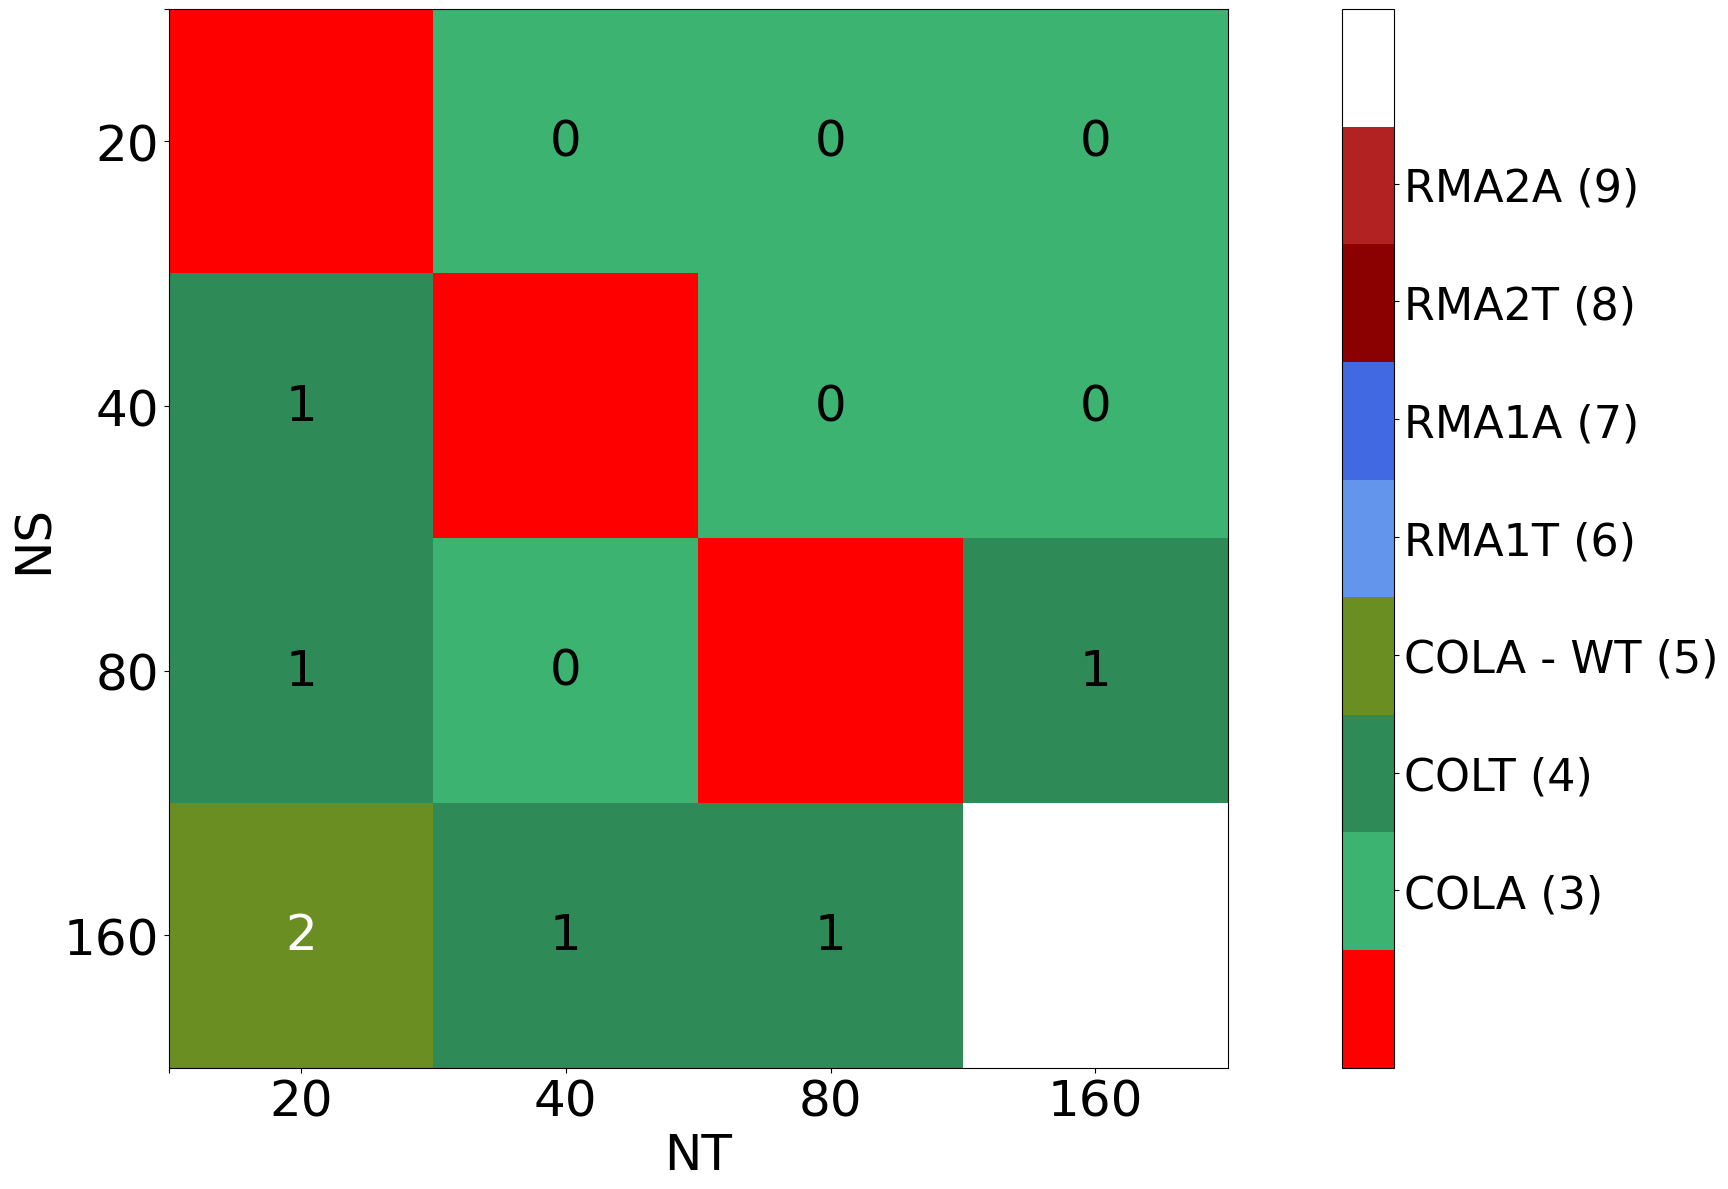

In [19]:
#Crea un heatmap teniendo en cuenta los colores anteriores
f=plt.figure(figsize=(24, 12))
ax=f.add_subplot(111)
index_plot = 0

myColors = get_plot_colors(index_plot, True)
cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))
im = ax.imshow(heatmap,cmap=cmap,interpolation='nearest')

# Loop over data dimensions and create text annotations.
used_aux=0
for i in range(len(processes)):
    for j in range(len(processes)):
        if i!=j:
            aux_color="white"
            if 0 <= heatmap[i, j] <= 1 or 4 <= heatmap[i, j] <= 7: # El 1 puede necesitar texto en negro para ser visible
                aux_color="black"
            results_index = i*len(processes) +j-used_aux
            #text = str(results[results_index]).translate(str.maketrans({'[': '', ']': '', ' ': ''}))
            text = str(heatmap[i][j])
            ax.text(j, i, text, ha="center", va="center", color=aux_color, fontsize=36)
        else:
            used_aux+=1
#Sarteco Names
labelsMethods_aux = ['COLS (0)',
                     'RMA1S (1)', 'RMA2S (2)',
                     'COLA (3)', 'COLT (4)',
                     'COLA - WT (5)', 
                     'RMA1T (6)', 'RMA1A (7)',
                     'RMA2T (8)', 'RMA2A (9)']
#labelsMethods_aux = [#'B Hypercube (0)', 
#                     'B Iterative Diffusive (1)',
#                     'M (2)',
                     #'M Hypercube (3)', 
#                     'M Iterative Diffusive (4)'
#                    ]
            

colorbar=f.colorbar(im, ax=ax)
tick_bar = []
for i in range(len(used_config)):
    #tick_bar.append(0.41 + i*0.96) #Config de 24 valores
    #tick_bar.append(0.4 + i*0.95) #Config de 17 valores
    #tick_bar.append(0.37 + i*0.92) #Config de 12 valores
    #tick_bar.append(0.36 + i*0.91) #Config de 10 valores
    #tick_bar.append(0.35 + i*0.9) #Config de 9 valores
    #tick_bar.append(0.35 + i*0.89) #Config de 8 valores
    tick_bar.append(0.34 + i*0.89) #Config de 10 valores
    #tick_bar.append(0.3 + i*0.83) #Config de 5 valores
    #tick_bar.append(0.3 + i*0.82) #Config de 4 valores
    #tick_bar.append(0.28 + i*0.78) #Config de 3 valores
colorbar.set_ticks(tick_bar) 
colorbar.set_ticklabels(labelsMethods_aux[3:])
colorbar.ax.tick_params(labelsize=32)
ax.set_ylabel("NS", fontsize=36)
ax.set_xlabel("NT", fontsize=36)

tick_labels = ['']+processes
ax.set_xticks([-0.5, 0, 1, 2, 3])
ax.set_yticks([-0.5, 0, 1, 2, 3])
ax.set_xticklabels(tick_labels, fontsize=36)
ax.set_yticklabels(tick_labels, fontsize=36)

f.tight_layout()
print("Filename: Heatmap_"+tipo+".png")
f.savefig("Images/Heatmap_"+tipo+".jpeg", format="jpeg", dpi=300)

In [20]:
aux_array = [] #Counts all
for data in results:
    aux_array+=data
aux_results, aux_counts = np.unique(aux_array, return_counts=True)
print(aux_results)
print(aux_counts)

aux_array = [0] * len(results) # Counts ganador celda
for index in range(len(results)):
    aux_array[index] = results[index][0]
aux_results, aux_counts = np.unique(aux_array, return_counts = True)
print(aux_results)
print(aux_counts)


[0 1 2]
[8 6 2]
[0 1 2]
[6 5 1]


In [22]:
def normalize_arrays(arrays, norm_array):
    new_arrays = arrays.copy()
    for index in range(len(new_arrays)):
        new_arrays[index] = np.divide(norm_array, new_arrays[index])
    return new_arrays

def create_labels_lineplot(used_direction, user_condition=lambda a, b: True):
    labels_aux = []
    if used_direction == 's':
        for ns_aux in processes:
            for np_aux in processes:
                if used_direction=='s' and np_aux > ns_aux and np_aux != ns_aux and user_condition(np_aux, ns_aux):
                    new_label = "(" + str(np_aux) + "→" + str(ns_aux) + ")"
                    labels_aux.append(new_label)
    else:
        for np_aux in processes:
            for ns_aux in processes:
                if ((used_direction=='e' and np_aux < ns_aux) or used_direction=='a') and np_aux != ns_aux and user_condition(np_aux, ns_aux):
                    new_label = "(" + str(np_aux) + "→" + str(ns_aux) + ")"
                    labels_aux.append(new_label)
    return labels_aux

def add_missing_data(plot_data, procsLists, biggestProcList):
    expected_len = len(biggestProcList)
    for data_i in range(len(plot_data)):
        data = plot_data[data_i]
        if len(data) < expected_len:
            actual_list = procsLists[data_i]
            for index in range(expected_len):
                if not (biggestProcList[index] in actual_list):
                    data.insert(index,-1)
                    
    return plot_data

def reorder_data(plot_data, actual_order, expected_order):
    ordered_indexes = []
    len_order = len(actual_order)
    for index in range(len_order):
        actual_order[index] = str(actual_order[index]).replace(", ", "→")
    for index in range(len_order):
        ordered_indexes.append(actual_order.index(expected_order[index]))

    for index in range(len(plot_data)):
        old_array = plot_data[index]
        new_array = []
        for i in ordered_indexes:
            new_array.append(old_array[i])
        plot_data[index] = new_array

    return plot_data

def remove_missing_data(x_pos, y_data):
    new_pos = list(x_pos)
    while -1 in y_data:
        index = y_data.index(-1)
        new_pos.pop(index)
        y_data.remove(-1)
    return new_pos, y_data

def data_constraints(test_parameter='T_Malleability', used_direction='a'):
    if test_parameter == 'alpha':
        name_fig="Alpha_"
        real_parameter='Alpha'
        name_legend = "Values of α"
        horiz_line = True
        allow_all = False
        used_config = configurations_simple
        data_aux = grouped_aggM[grouped_aggM[real_parameter] > 0]
    elif test_parameter == 'T_Malleability':
        name_fig="Malleability_"
        real_parameter='T_Malleability'
        name_legend = "Time(s)"
        horiz_line = False
        allow_all = True
        used_config = configurations_simple
        data_aux = grouped_aggM
    elif test_parameter == 'T_Spawn':
        name_fig="Spawn_"
        real_parameter='T_spawn'
        name_legend = "Time(s)"
        horiz_line = False
        allow_all = True
        used_config = configurations_simple
        data_aux = grouped_aggM
    elif test_parameter == 'T_SR':
        name_fig="SynchRed_"
        real_parameter='T_SR'
        name_legend = "Time(s)"
        horiz_line = False
        allow_all = True
        used_config = configurations_simple
        data_aux = grouped_aggM
    elif test_parameter == 'T_AR':
        name_fig="AsynchRed_"
        real_parameter='T_AR'
        name_legend = "Time(s)"
        horiz_line = False
        allow_all = False
        used_config = configurations_simple
        data_aux = grouped_aggM[grouped_aggM[real_parameter] > 0]
    elif test_parameter == 'T_Redistribution':
        name_fig="Redistribution_"
        real_parameter='T_Redistribution'
        name_legend = "Time(s)"
        horiz_line = False
        allow_all = True
        used_config = configurations_simple
        data_aux = grouped_aggM
    elif test_parameter == 'omega':
        name_fig="Omega_"
        real_parameter='Omega'
        name_legend = "Values of ω"
        horiz_line = True
        allow_all = False
        used_config = configurations
        data_aux = grouped_aggLAsynch[grouped_aggLAsynch[real_parameter] > 0]
    elif test_parameter == 'iters_count':
        name_fig="Iters_"
        real_parameter='Asynch_Iters'
        name_legend = "Overlapped Iterations"
        horiz_line = False
        allow_all = False
        used_config = configurations_simple
        #data_aux = grouped_aggLAsynch[grouped_aggLAsynch[real_parameter] > 0]
        data_aux = grouped_aggM[grouped_aggM[real_parameter] > 0]
    if used_direction=='s':
        data_aux=data_aux.query('NP > NC')
        name_fig= name_fig+"Shrink"
    elif used_direction=='e':
        data_aux=data_aux.query('NP < NC')
        name_fig= name_fig+"Expand"
    elif used_direction=='a':
        name_fig= name_fig+"All"
        
    results = [name_fig, real_parameter, name_legend, horiz_line, allow_all, used_config, data_aux]
    return results

def get_plot_data(test_parameter='T_Malleability', used_direction='a', normalize=False):
    results = data_constraints(test_parameter, used_direction)
    name_fig = results[0] #
    real_parameter = results[1]
    name_legend = results[2] # 
    horiz_line = results[3] #
    allow_all = results[4]
    used_config = results[5]
    data_aux = results[6]
    
    plot_data = []
    procsLists = []
    biggestProcList = []
    for config in used_config:
        #print(config)
        if config[0] > 0 or allow_all:
            dataLists,newProcsLists = get_config_data(real_parameter, data_aux, config)
            dataLists = list(filter(lambda x: x != float('infinity'), dataLists))
            plot_data.append(dataLists)
            procsLists.append(newProcsLists)
            if len(biggestProcList) <= len(newProcsLists):
                biggestProcList = newProcsLists

    #labels_aux = create_labels_lineplot(used_direction, lambda a, b: a == 160 or b == 160)
    labels_aux = create_labels_lineplot(used_direction)
    plot_data = add_missing_data(plot_data, procsLists, biggestProcList)
    plot_data = reorder_data(plot_data, biggestProcList, labels_aux)
    if normalize:
        to_norm = [plot_data[0], plot_data[1], plot_data[3], plot_data[4]]
        plot_data = normalize_arrays(to_norm, plot_data[2])
        procsLists.pop(2)
    results = [name_fig, name_legend, horiz_line, plot_data, procsLists, biggestProcList, labels_aux]
    return results

[1.0, 16.0, 23.5, 20.5, 6.0, 3.0, 10.0, 10.5, 6.0, 4.0, 6.0, 5.5]
[2.0, 16.5, 24.5, 21.0, 6.0, 4.0, 7.0, 11.0, 6.0, 5.0, 7.0, 6.0]
[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0]
[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0]


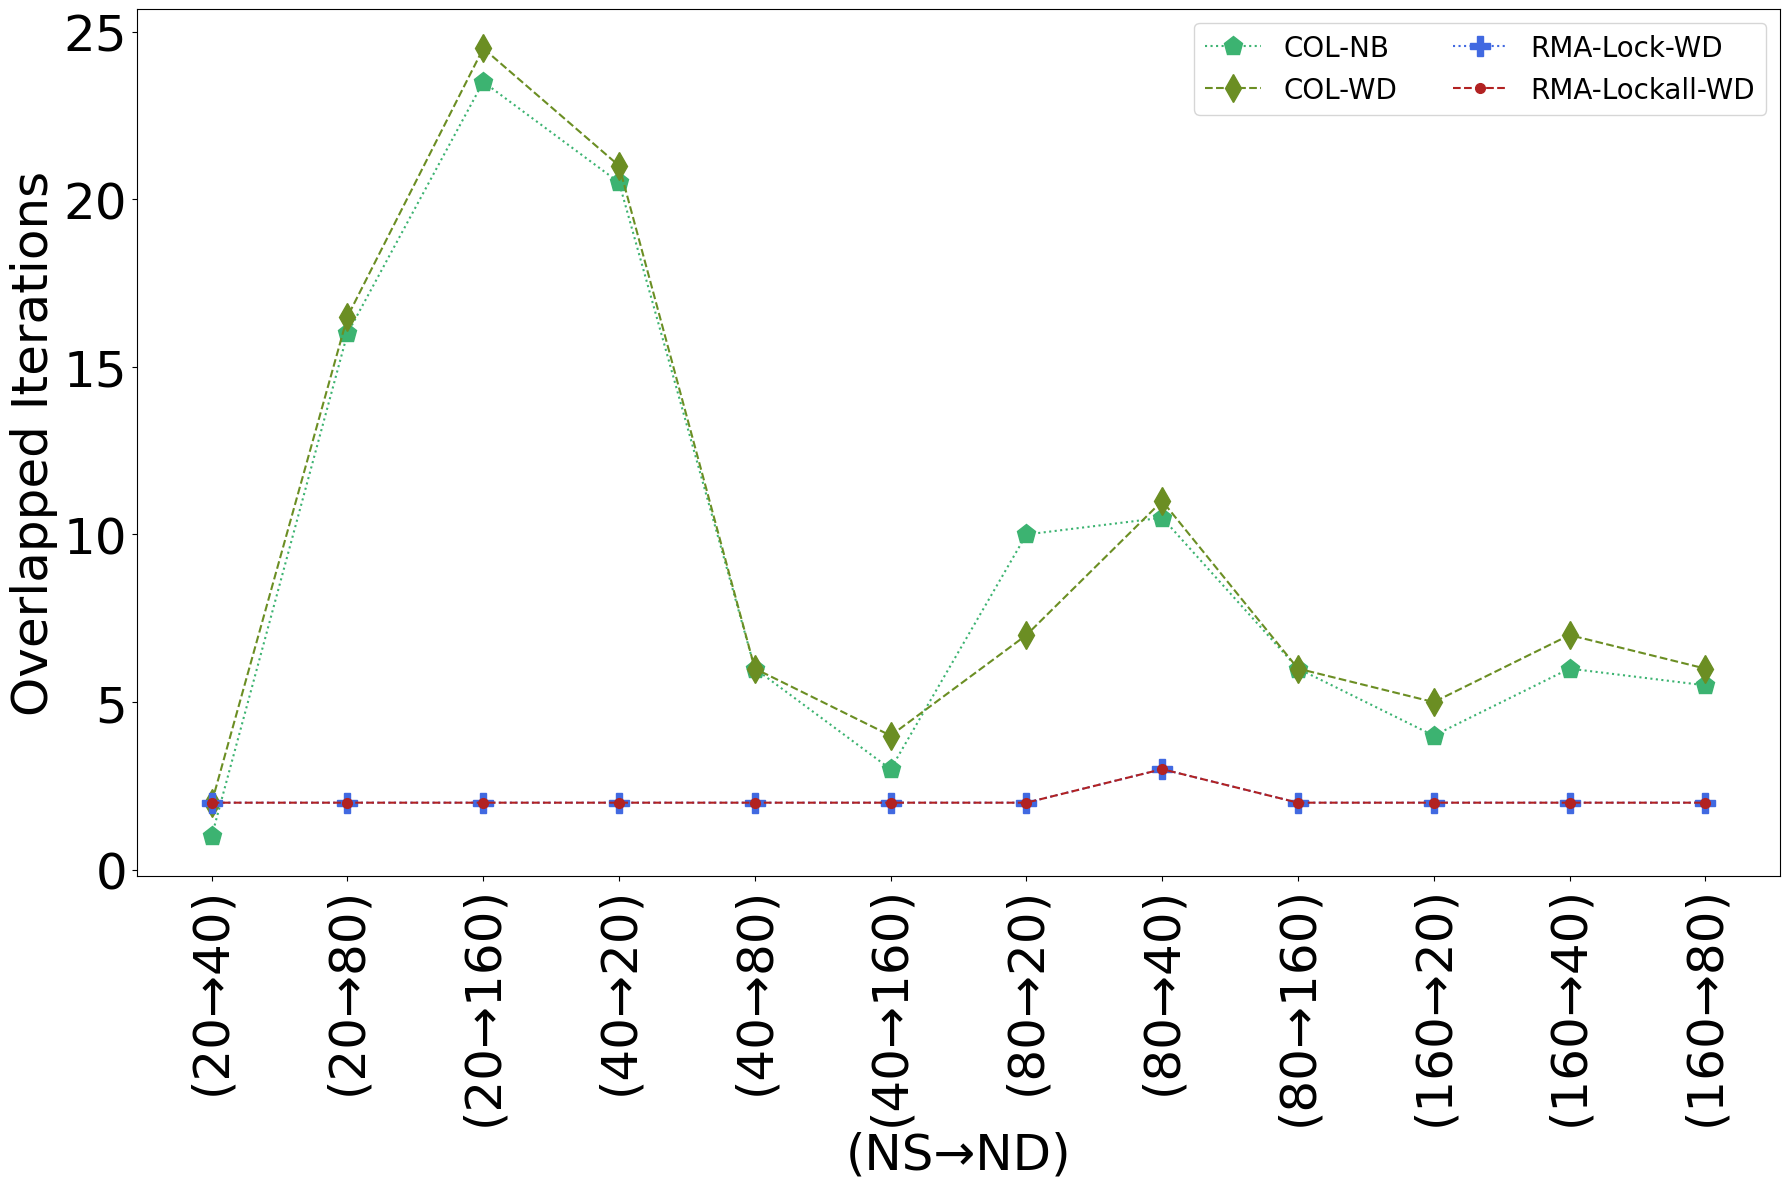

In [28]:
used_direction='a'
test_parameter='iters_count' #Valores son "alpha" o "omega"
normalize = False
index_plot = 0

results = get_plot_data(test_parameter, used_direction, normalize)
name_fig = results[0]
name_legend = results[1]
horiz_line = results[2]
plot_data = results[3]
procsLists = results[4]
biggestProcList = results[5]
labels_aux = results[6]

colors_m = get_plot_colors(index_plot)
labelsMethods_aux = get_plot_labels(index_plot)

offset_plot_index = len(labelsMethods_aux) - len(plot_data)

f=plt.figure(figsize=(18, 12))
ax=f.add_subplot(111)
x = np.arange(len(labels_aux))

#ignore = [3,4,5,6,7,8,9]
ignore = [4,6,8]
#ignore = []
for real_index in range(len(plot_data)):
    plot_index = real_index + offset_plot_index
    if ignore and plot_index in ignore:
        continue
    array_aux = plot_data[real_index]
    if len(procsLists[real_index]) != len(biggestProcList):
        x, array_aux = remove_missing_data(x, array_aux)
    else:
        x_aux = x
    print(array_aux)
    
    ax.plot(x_aux, array_aux, color=colors_m[plot_index%len(colors_m)], linestyle=linestyle_m[plot_index%len(linestyle_m)], \
        marker=markers_m[plot_index%len(markers_m)], markersize=14, label=labelsMethods_aux[plot_index])

ax.set_xlabel("(NS→ND)", fontsize=36)
ax.set_ylabel(name_legend, fontsize=36)
if horiz_line or normalize:
    ax.axhline(y=1, color='black', linestyle='--')
    mod_yticks = ax.get_yticks()
    mod_yticks[np.where(mod_yticks == 0)] = 1
    ax.set_yticks(mod_yticks)
plt.xticks(x, labels_aux,rotation=90)

ax.tick_params(axis='both', which='major', labelsize=36)
ax.tick_params(axis='both', which='minor', labelsize=36)
plt.legend(loc='best', fontsize=20,ncol=2,framealpha=0.8)
        
#ax.set_ylim(0, 10.3)
f.tight_layout()
f.savefig("Images/LinePlot_"+name_fig+".png", format="png", dpi=300)

[1.0, 16.0, 23.5, 20.5, 6.0, 3.0, 10.0, 10.5, 6.0, 4.0, 6.0, 5.5]
[2.0, 16.5, 24.5, 21.0, 6.0, 4.0, 7.0, 11.0, 6.0, 5.0, 7.0, 6.0]
[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0]
[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0]


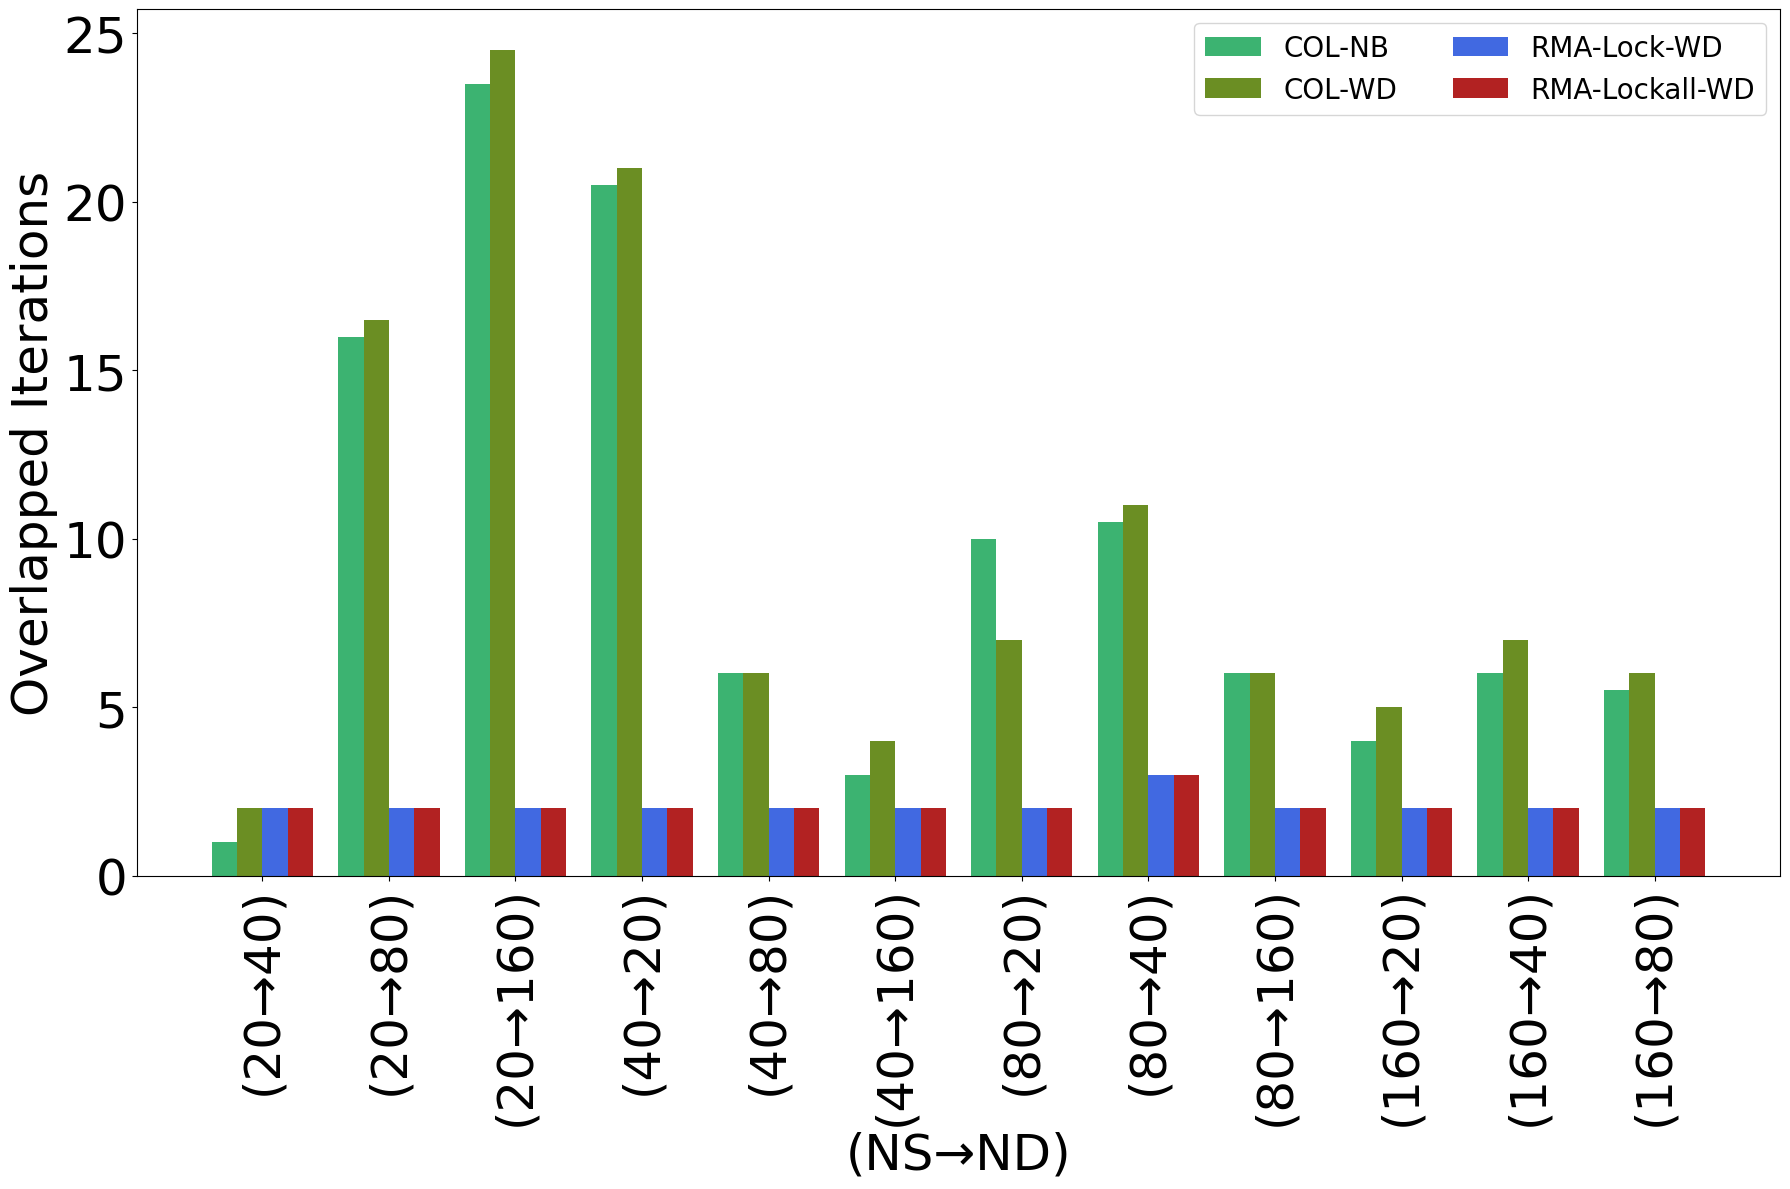

In [33]:
used_direction='a'
test_parameter='iters_count' #Valores son "alpha" o "omega"
normalize = False
index_plot = 0
#ignore = [3,4,5,6,7,8,9]
ignore = [0,1,2,4,6,8]
#ignore = [0,1,2,3,5,7,9]
#ignore=[]

results = get_plot_data(test_parameter, used_direction, normalize)
name_fig = results[0]
name_legend = results[1]
horiz_line = results[2]
plot_data = results[3]
procsLists = results[4]
biggestProcList = results[5]
labels_aux = results[6]

colors_m = get_plot_colors(index_plot)
labelsMethods_aux = get_plot_labels(index_plot)

offset_plot_index = len(labelsMethods_aux) - len(plot_data)

to_norm = []
speedups_labels = []
for index in range(len(plot_data)):
    used_index = index + offset_plot_index
    if not (ignore and used_index in ignore):
        to_norm.append(plot_data[index])
speedups = normalize_arrays(to_norm, to_norm[0])
speedups_labels.append(["1x" for number in speedups[0]])
for speed in speedups[1:]:
    speedups_labels.append(["%.2fx" % number for number in speed])

f=plt.figure(figsize=(18, 12))
ax=f.add_subplot(111)
x = np.arange(len(labels_aux))
initial_offset = -0.4


width = 0.8 / (len(labelsMethods_aux) - len(ignore)) # 0.8 Es el tamaño máximo que puede ocupar cada set
ignored_indexes=0
for real_index in range(len(plot_data)):
    plot_index = real_index + offset_plot_index
    if ignore and plot_index in ignore:
        ignored_indexes+=1
        continue
    array_aux = plot_data[real_index]
    if len(procsLists[real_index]) != len(biggestProcList):
        x, array_aux = remove_missing_data(x, array_aux)
    else:
        x_aux = x
    print(array_aux)
    
    speed_aux = speedups_labels[real_index-ignored_indexes]
    offsets = []
    for pos_ind in range(len(x_aux)):
        pos = x_aux[pos_ind] + initial_offset + (real_index-ignored_indexes) * width
        offsets.append(pos)
    #print(offsets)
    rects = ax.bar(offsets, array_aux, width=width, align='edge', color=colors_m[plot_index%len(colors_m)], label=labelsMethods_aux[plot_index])
    #ax.bar_label(rects, labels=speed_aux, padding=3, fontsize=14, rotation=90)
    #ax.bar_label(rects, padding=3, fontsize=12, rotation=40)
    
ax.set_xlabel("(NS→ND)", fontsize=36)
ax.set_ylabel(name_legend, fontsize=36)
if horiz_line or normalize:
    ax.axhline(y=1, color='black', linestyle='--')
    mod_yticks = ax.get_yticks()
    mod_yticks[np.where(mod_yticks == 0)] = 1
    ax.set_yticks(mod_yticks)
plt.xticks(x, labels_aux,rotation=90)

ax.tick_params(axis='both', which='major', labelsize=36)
ax.tick_params(axis='both', which='minor', labelsize=36)
plt.legend(loc='upper right', fontsize=20,ncol=2,framealpha=0.8)
        
new_ylim = list(ax.get_ylim())
new_ylim[0] = 0
new_ylim[1] = new_ylim[1] * 1.08
#ax.set_ylim(new_ylim)
f.tight_layout()
f.savefig("Images/BarPlot_"+name_fig+".png", format="png", dpi=300)

/tmp/ipykernel_429668/3314077064.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels_aux, fontsize=32, rotation=60)
/tmp/ipykernel_429668/3314077064.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labelsMethods_aux, fontsize=36)


Filename: HeatmapTEST_Malleability_All.png


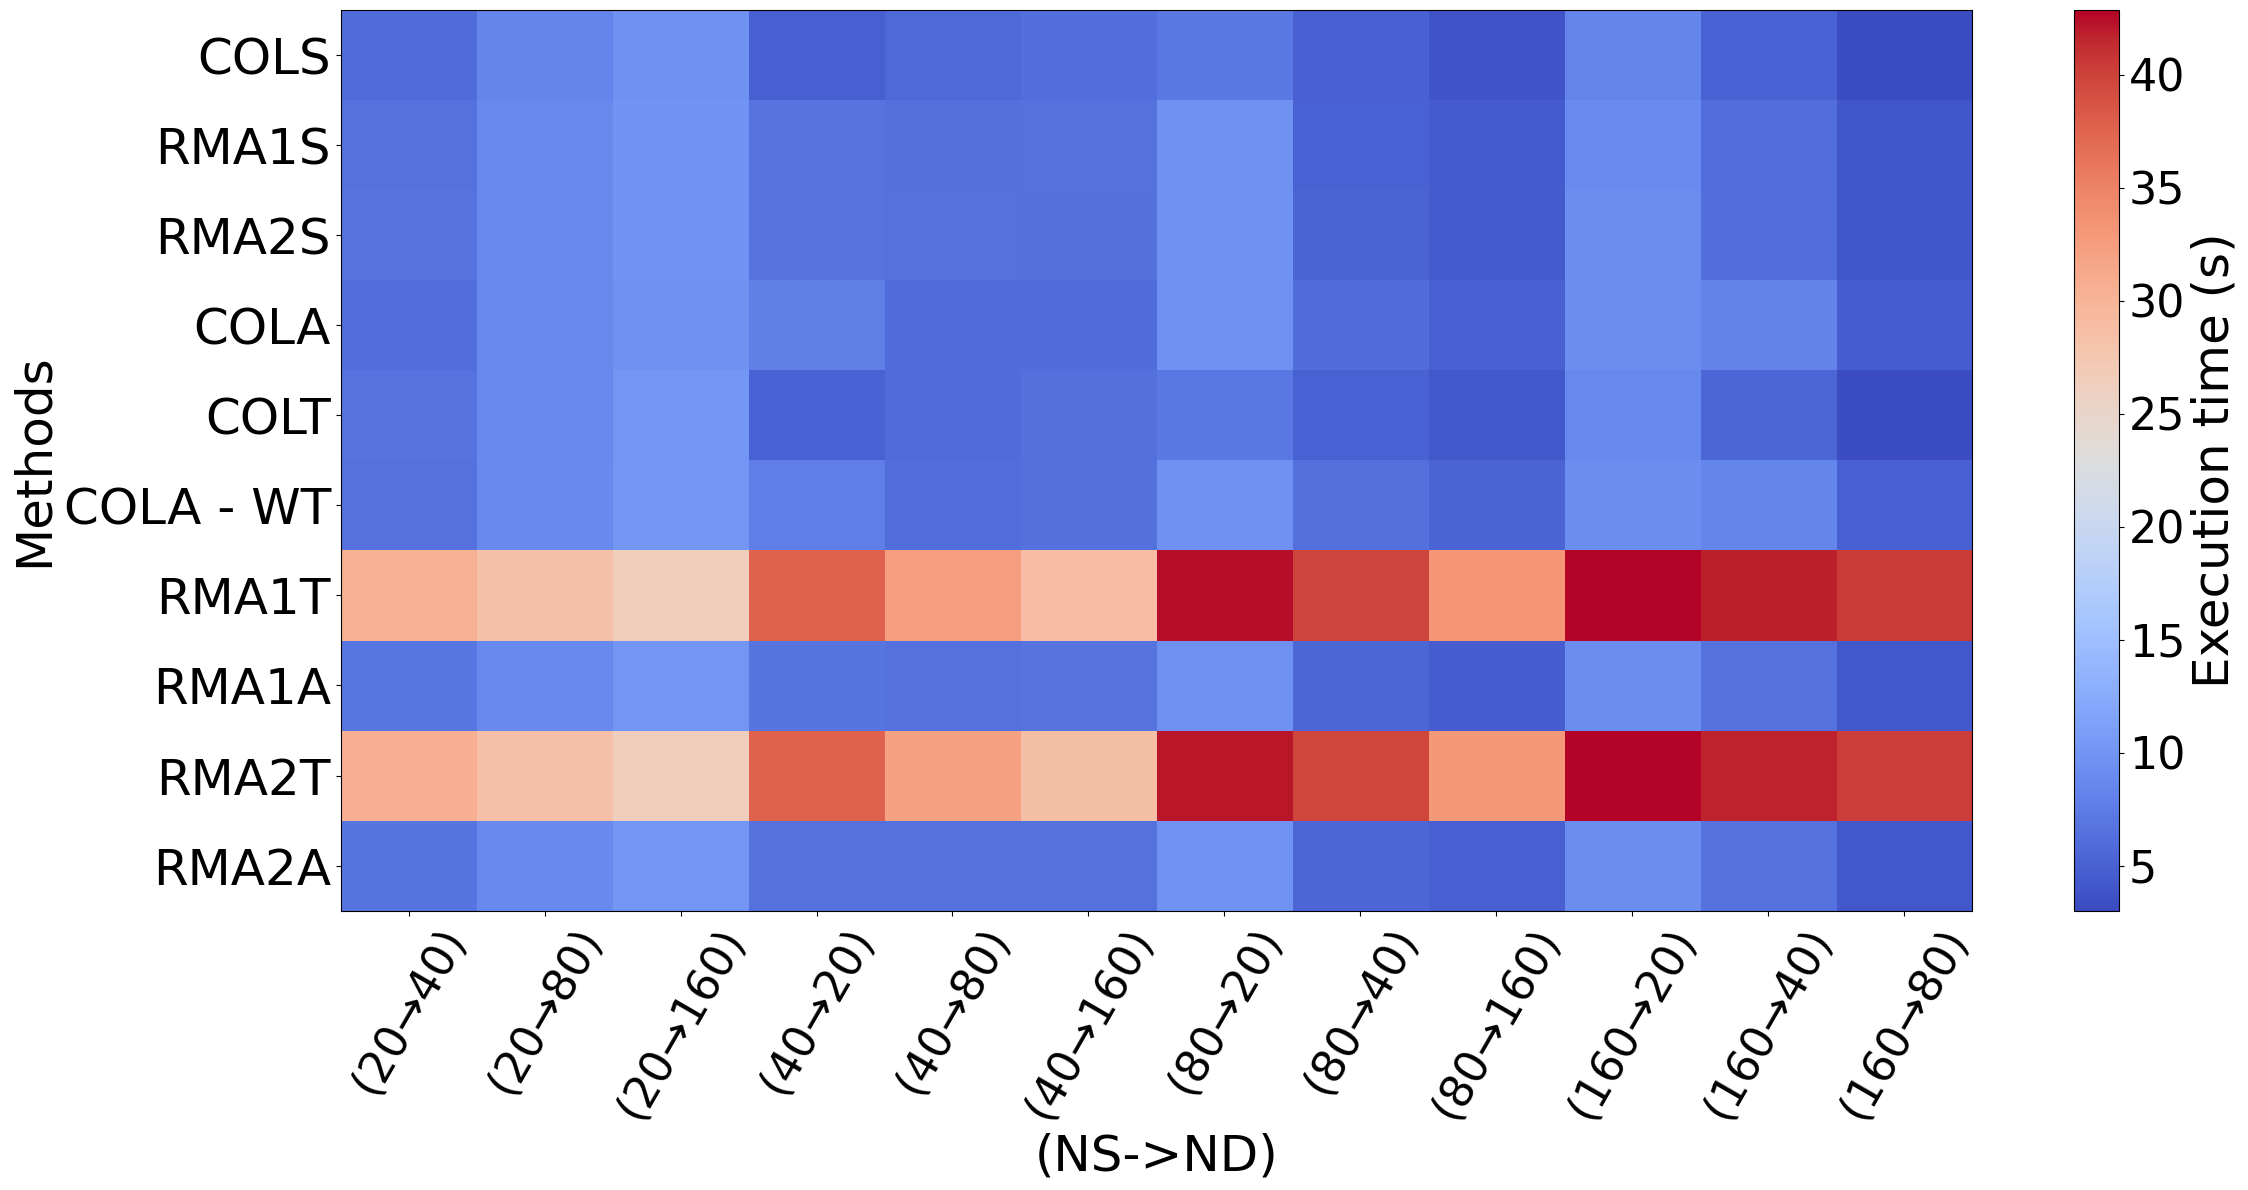

In [84]:
used_direction='a'
test_parameter='T_Malleability' #Valores son "alpha" o "omega"
normalize = False
index_plot = 0

results = get_plot_data(test_parameter, used_direction, normalize)
name_fig = results[0]
name_legend = results[1]
horiz_line = results[2]
plot_data = results[3]
procsLists = results[4]
biggestProcList = results[5]
labels_aux = results[6]

colors_m = get_plot_colors(index_plot)
labelsMethods_aux = get_plot_labels(index_plot)

ignore = []
for ig_index in sorted(ignore, reverse=True):
    labelsMethods_aux.pop(ig_index)
    plot_data.pop(ig_index)

f, ax=plt.subplots(figsize=(24, 12))
im = ax.imshow(plot_data, cmap="coolwarm", aspect="auto")
colorbar=f.colorbar(im, ax=ax)

colorbar.set_label("Execution time (s)", fontsize=36)
colorbar.ax.tick_params(labelsize=32)
ax.set_ylabel("Methods", fontsize=36)
ax.set_xlabel("(NS->ND)", fontsize=36)
ax.set_xticklabels(labels_aux, fontsize=32, rotation=60)
ax.set_xticks(np.arange(len(labels_aux)))
ax.set_yticklabels(labelsMethods_aux, fontsize=36)
ax.set_yticks(np.arange(len(labelsMethods_aux)))

f.tight_layout()
print("Filename: HeatmapTEST_"+name_fig+".png")
f.savefig("Images/HeatmapTEST_"+name_fig+".png", format="png", dpi=300)

[ 6.84239192  9.76487871 11.57690925  7.56969684  6.29745239  6.59682314
  8.27799944  6.02056242  4.52907422  9.11664361  6.05979     3.58548731]
[30.42153549 29.42331017 27.70526398 39.87091168 32.50820433 28.83110457
 43.38267918 40.63362676 33.47509853 43.03478464 42.15889254 40.57548033]
[30.57097244 29.35263718 27.82558907 39.90035733 32.30016981 28.65901976
 43.07274265 40.35504705 33.13206188 43.09663996 42.13882723 40.53808104]


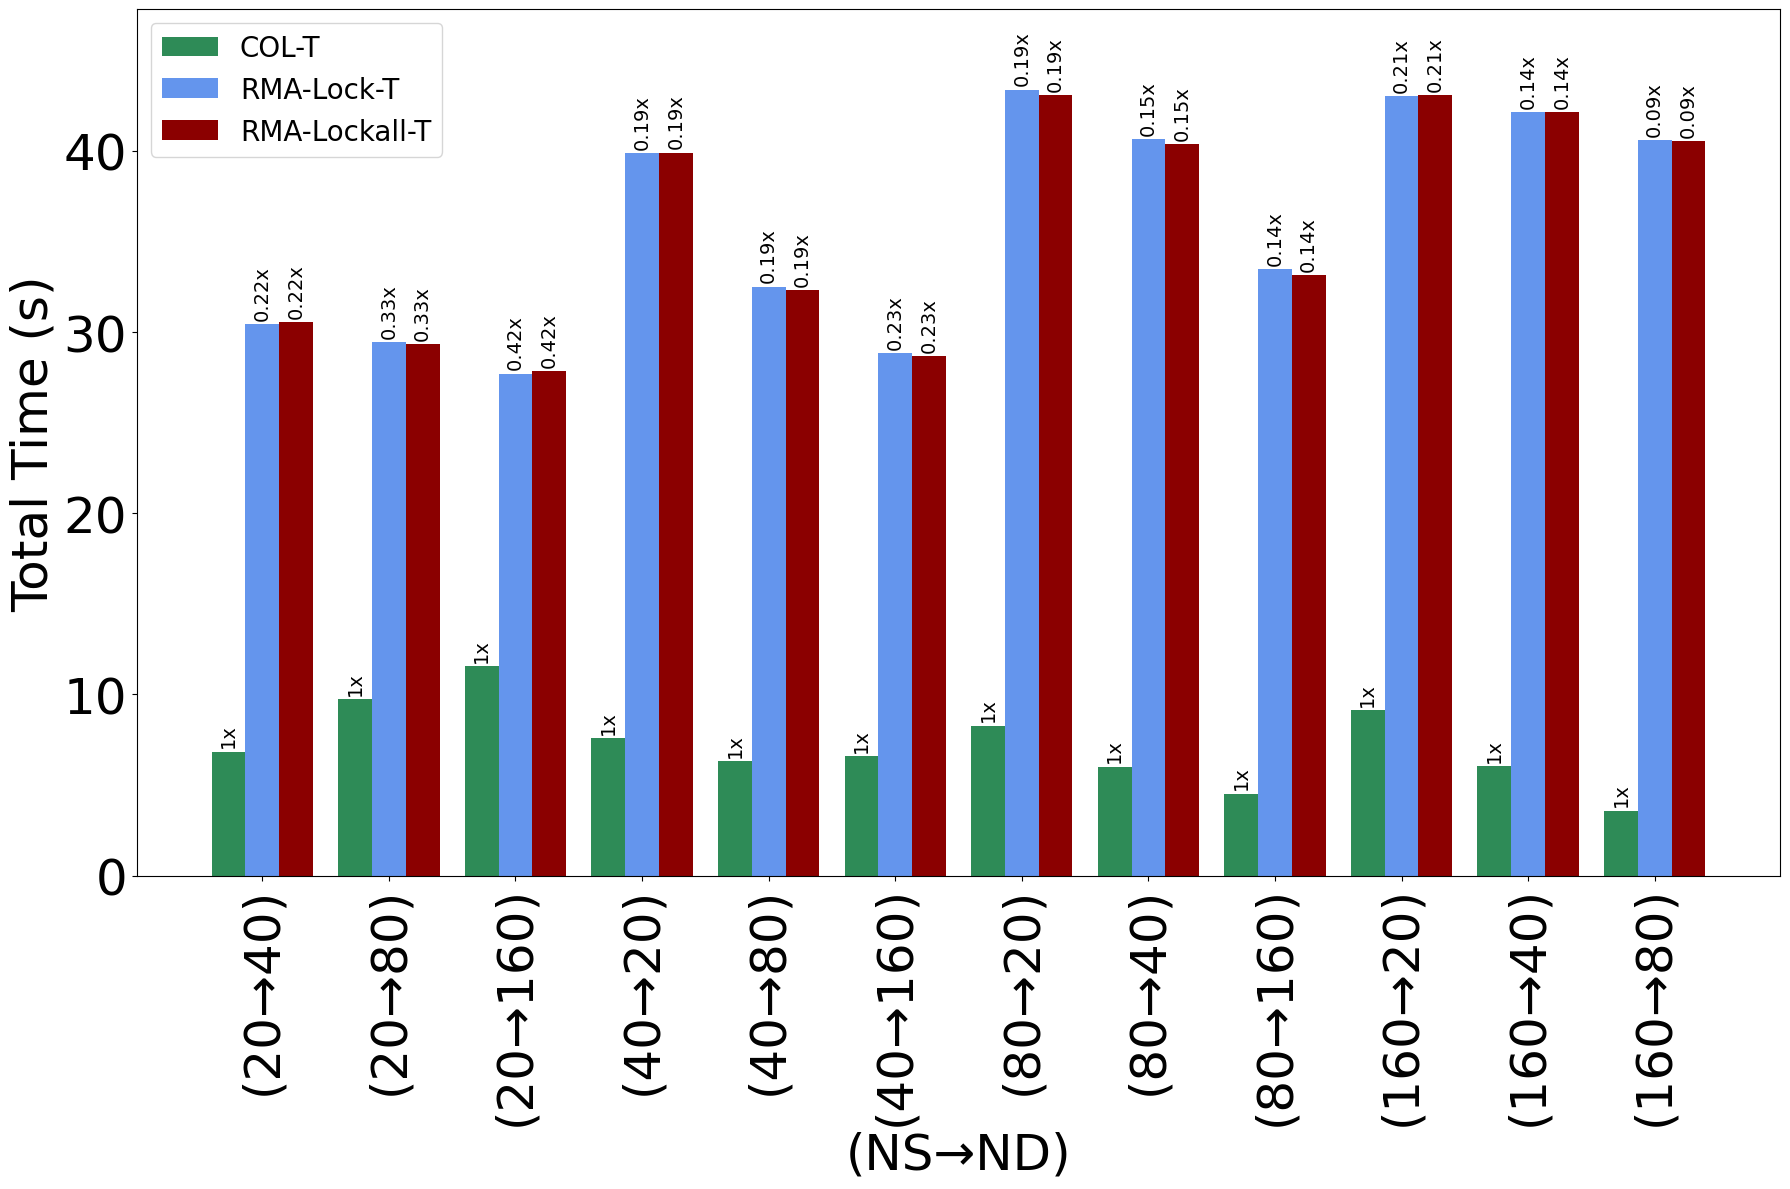

In [41]:
used_direction='a'
index_plot = 0
ignore = [0,1,2,4,6,8]
ignore = [0,1,2,3,5,7,9]

labels_aux = create_labels_lineplot(used_direction)
colors_m = get_plot_colors(index_plot)
labelsMethods_aux = get_plot_labels(index_plot)


mall_times = np.zeros(shape=(len(labelsMethods_aux), len(labels_aux)))
n_it = np.zeros(shape=(len(labelsMethods_aux), len(labels_aux)))
t_it = np.zeros(shape=(len(labels_aux)))
for index_config in range(0, len(configurations)):
    
    config = configurations_simple[index_config]
    if config[0] == 0:
        continue
    dataLists,newProcsLists = get_config_data('Asynch_Iters', grouped_aggM, config)
    aux = np.array(dataLists, dtype='float32')
    n_it[index_config] = aux
    if ignore and index_config in ignore: # We need the iters from all the avail methods
        continue
    
    dataLists,newProcsLists = get_config_data('T_Malleability', grouped_aggM, config)
    aux = np.array(dataLists, dtype='float32')
    mall_times[index_config] = aux
    
m_p = np.max(n_it, axis=0) 
for i_pair in range(len(newProcsLists)):
    nd = newProcsLists[i_pair][1]
    t_it[i_pair] = grouped_aggLSynch.loc[nd,'T_iter']
    
#print(mall_times)
#print(t_it)
#print(m_p)
#print(n_it)

plot_data = mall_times + t_it * (m_p-n_it)
plot_data = reorder_data(plot_data, newProcsLists, labels_aux)


offset_plot_index = len(labelsMethods_aux) - len(plot_data)
to_norm = []
speedups_labels = []
for index in range(len(plot_data)):
    used_index = index + offset_plot_index
    if not (ignore and used_index in ignore):
        to_norm.append(plot_data[index])
speedups = normalize_arrays(to_norm, to_norm[0])
speedups_labels.append(["1x" for number in speedups[0]])
for speed in speedups[1:]:
    speedups_labels.append(["%.2fx" % number for number in speed])

f=plt.figure(figsize=(18, 12))
ax=f.add_subplot(111)
x = np.arange(len(labels_aux))
initial_offset = -0.4


width = 0.8 / (len(labelsMethods_aux) - (len(ignore) + offset_plot_index)) # 0.8 Es el tamaño máximo que puede ocupar cada set
ignored_indexes=0
for real_index in range(len(plot_data)):
    plot_index = real_index + offset_plot_index
    if ignore and plot_index in ignore:
        ignored_indexes+=1
        continue
    array_aux = plot_data[real_index]
#    if len(procsLists[real_index]) != len(biggestProcList):
#        x, array_aux = remove_missing_data(x, array_aux)
#    else:
    x_aux = x
    print(array_aux)
    
    speed_aux = speedups_labels[real_index-ignored_indexes]
    offsets = []
    for pos_ind in range(len(x_aux)):
        pos = x_aux[pos_ind] + initial_offset + (real_index-ignored_indexes) * width
        offsets.append(pos)
    #print(offsets)
    rects = ax.bar(offsets, array_aux, width=width, align='edge', color=colors_m[plot_index%len(colors_m)], label=labelsMethods_aux[plot_index])
    ax.bar_label(rects, labels=speed_aux, padding=3, fontsize=14, rotation=90)
    #ax.bar_label(rects, padding=3, fontsize=12, rotation=40)
    
ax.set_xlabel("(NS→ND)", fontsize=36)
ax.set_ylabel("Total Time (s)", fontsize=36)
plt.xticks(x, labels_aux,rotation=90)

ax.tick_params(axis='both', which='major', labelsize=36)
ax.tick_params(axis='both', which='minor', labelsize=36)
plt.legend(loc='upper left', fontsize=20,ncol=1,framealpha=0.8)
        
new_ylim = list(ax.get_ylim())
new_ylim[0] = 0
new_ylim[1] = new_ylim[1] * 1.05
ax.set_ylim(new_ylim)
f.tight_layout()
f.savefig("Images/BarPlot_test.png", format="png", dpi=300)

In [ ]:
[6.650786, 8.718578, 10.041008, 5.125826999999999, 5.959936, 6.4007505, 7.178258, 5.0625325, 4.2022865, 8.6278695, 5.484972, 3.2479709999999997]
[30.4215355, 28.5120165, 26.234721, 37.671429, 32.305693500000004, 28.765748000000002, 42.527325, 39.867202500000005, 33.279027, 42.790398499999995, 41.77568, 40.372969]
[30.570971999999998, 28.441344, 26.3550455, 37.700876, 32.097659, 28.593663, 42.217388, 39.5886235, 32.9359895, 42.852252500000006, 41.755615, 40.3355695]

[ 6.84239192  8.85358484 10.1063655   5.37021384  6.09494264  6.53146564 7.42264494  5.25413842  4.33300172  8.87225661  5.676578    3.38297756]
[30.42153549 28.5120163  26.23472023 37.67142868 32.30569458 28.76574707 42.52732468 39.86720276 33.27902603 42.79039764 41.77568054 40.37297058]
[30.57097244 28.44134331 26.35504532 37.70087433 32.09766006 28.59366226
 42.21738815 39.58862305 32.93598938 42.85225296 41.75561523 40.33557129]

In [ ]:
plot_data = []
procsLists = []
biggestProcList = []
count_iters ={}

#COMPUTE ASYNC
for index_config in range(3, len(configurations)):
    config = configurations_simple[index_config]
    # Get iters qty
    data_aux = grouped_aggM[grouped_aggM['Asynch_Iters'] > 0]
    dataLists_2,newProcsLists_aux = get_config_data('Asynch_Iters', data_aux, config)
    for index_res in range(len(newProcsLists_aux)):
        np_pair = newProcsLists_aux[index_res]
        if not (np_pair in count_iters):
            count_iters[np_pair] = dataLists_2[index_res]
        elif count_iters[np_pair] > dataLists_2[index_res]:
            count_iters[np_pair] = dataLists_2[index_res]
    
    
    dataLists,newProcsLists = get_config_data('T_Malleability', grouped_aggM, config)
    mall_t = np.array(dataLists, dtype='float32')
    
    t_t = mall_t
    print(t_t)
    #print(newProcsLists)
    plot_data.append(t_t)
    procsLists.append(newProcsLists)

print(count_iters)

#COMPUTE SYNC
for index_config in range(0, 3):
    # Get spawn data
    config = configurations_simple[index_config]
    dataLists,newProcsLists = get_config_data('T_Malleability', grouped_aggM, config)
    mall_t = np.array(dataLists, dtype='float32')
    
    dataLists = []
    for index_res in range(len(newProcsLists)):
        np_pair = newProcsLists[index_res]
        iter_time = grouped_aggLSynch.loc[np_pair[1],'T_iter']
        iter_qty = count_iters[np_pair]
        dataLists.append(iter_time * iter_qty)
    iters_t = np.array(dataLists, dtype='float32')
    t_t = mall_t + iters_t
    plot_data.insert(index_config, t_t)
    procsLists.insert(index_config, newProcsLists)
    
# PLOT DATA
biggestProcList = newProcsLists

labels_aux = create_labels_lineplot('a')
plot_data = add_missing_data(plot_data, procsLists, biggestProcList)
plot_data = reorder_data(plot_data, biggestProcList, labels_aux)

f=plt.figure(figsize=(18, 12))
ax=f.add_subplot(111)
x = np.arange(len(labels_aux))
ignore= [6,8]
#ignore= []
ordered_index = [0,3,4,5,1,2,6,7,8,9]
width = 0.8 / (len(labelsMethods_aux) - (len(ignore) + offset_plot_index)) # 0.8 Es el tamaño máximo que puede ocupar cada set
#for index in range(len(plot_data)):
for index in ordered_index:
    array_aux = plot_data[index]
    plot_index = index
    if len(procsLists[index]) != len(biggestProcList):
        x_aux, array_aux = remove_missing_data(x, array_aux)
    else:
        x_aux = x
    if ignore and plot_index in ignore:
        continue
    print(array_aux)
    
    #ax.plot(x_aux, array_aux, color=colors_m[plot_index%len(colors_m)], linestyle=linestyle_m[plot_index%len(linestyle_m)], \
    #    marker=markers_m[plot_index%len(markers_m)], markersize=14, label=labelsMethods_aux[plot_index])
    offsets = []
    for pos_ind in range(len(x_aux)):
        pos = x_aux[pos_ind] + initial_offset + (real_index-ignored_indexes) * width
        offsets.append(pos)
    rects = ax.bar(offsets, array_aux, width=width, align='edge', color=colors_m[plot_index%len(colors_m)], label=labelsMethods_aux[plot_index])

ax.set_xlabel("(NS,ND)", fontsize=28)
ax.set_ylabel("Total Time (s)", fontsize=28)
plt.xticks(x, labels_aux,rotation=90)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(axis='both', which='minor', labelsize=28)
ax.set_ylim(0, 10.5)
plt.legend(loc='best', fontsize=20,ncol=2,framealpha=0.8)
        
f.tight_layout()
f.savefig("Images/LinePlot_TEST.png", format="png")

[11.3795795, 11.5814555, 12.1888165, 11.831431, 9.7664885, 9.8909895, 15.0799735, 11.102908, 8.508270499999998, 15.808303500000001, 12.914542999999998, 8.795320499999999]
[11.783303, 13.0318845, 14.168893, 11.51613, 9.9840545, 10.329576, 14.076698, 10.565415999999999, 8.2047365, 15.571973, 10.8660175, 7.3661705]
[11.627013999999999, 11.974453, 12.390108999999999, 12.0113885, 10.159491, 10.285287, 15.582648500000001, 10.7947905, 8.7976925, 15.924733, 13.288875, 8.7746355]
[11.9074325, 12.8007375, 13.92425, 13.2201715, 10.5020955, 10.3634775, 16.2672495, 10.6461395, 8.4452155, 15.482799, 11.7283665, 8.2788605]
[11.797066000000001, 12.8120005, 13.828557499999999, 12.959392000000001, 10.42292, 10.278501, 16.356983, 10.729872499999999, 8.450872, 15.520586999999999, 11.7590865, 8.246694999999999]


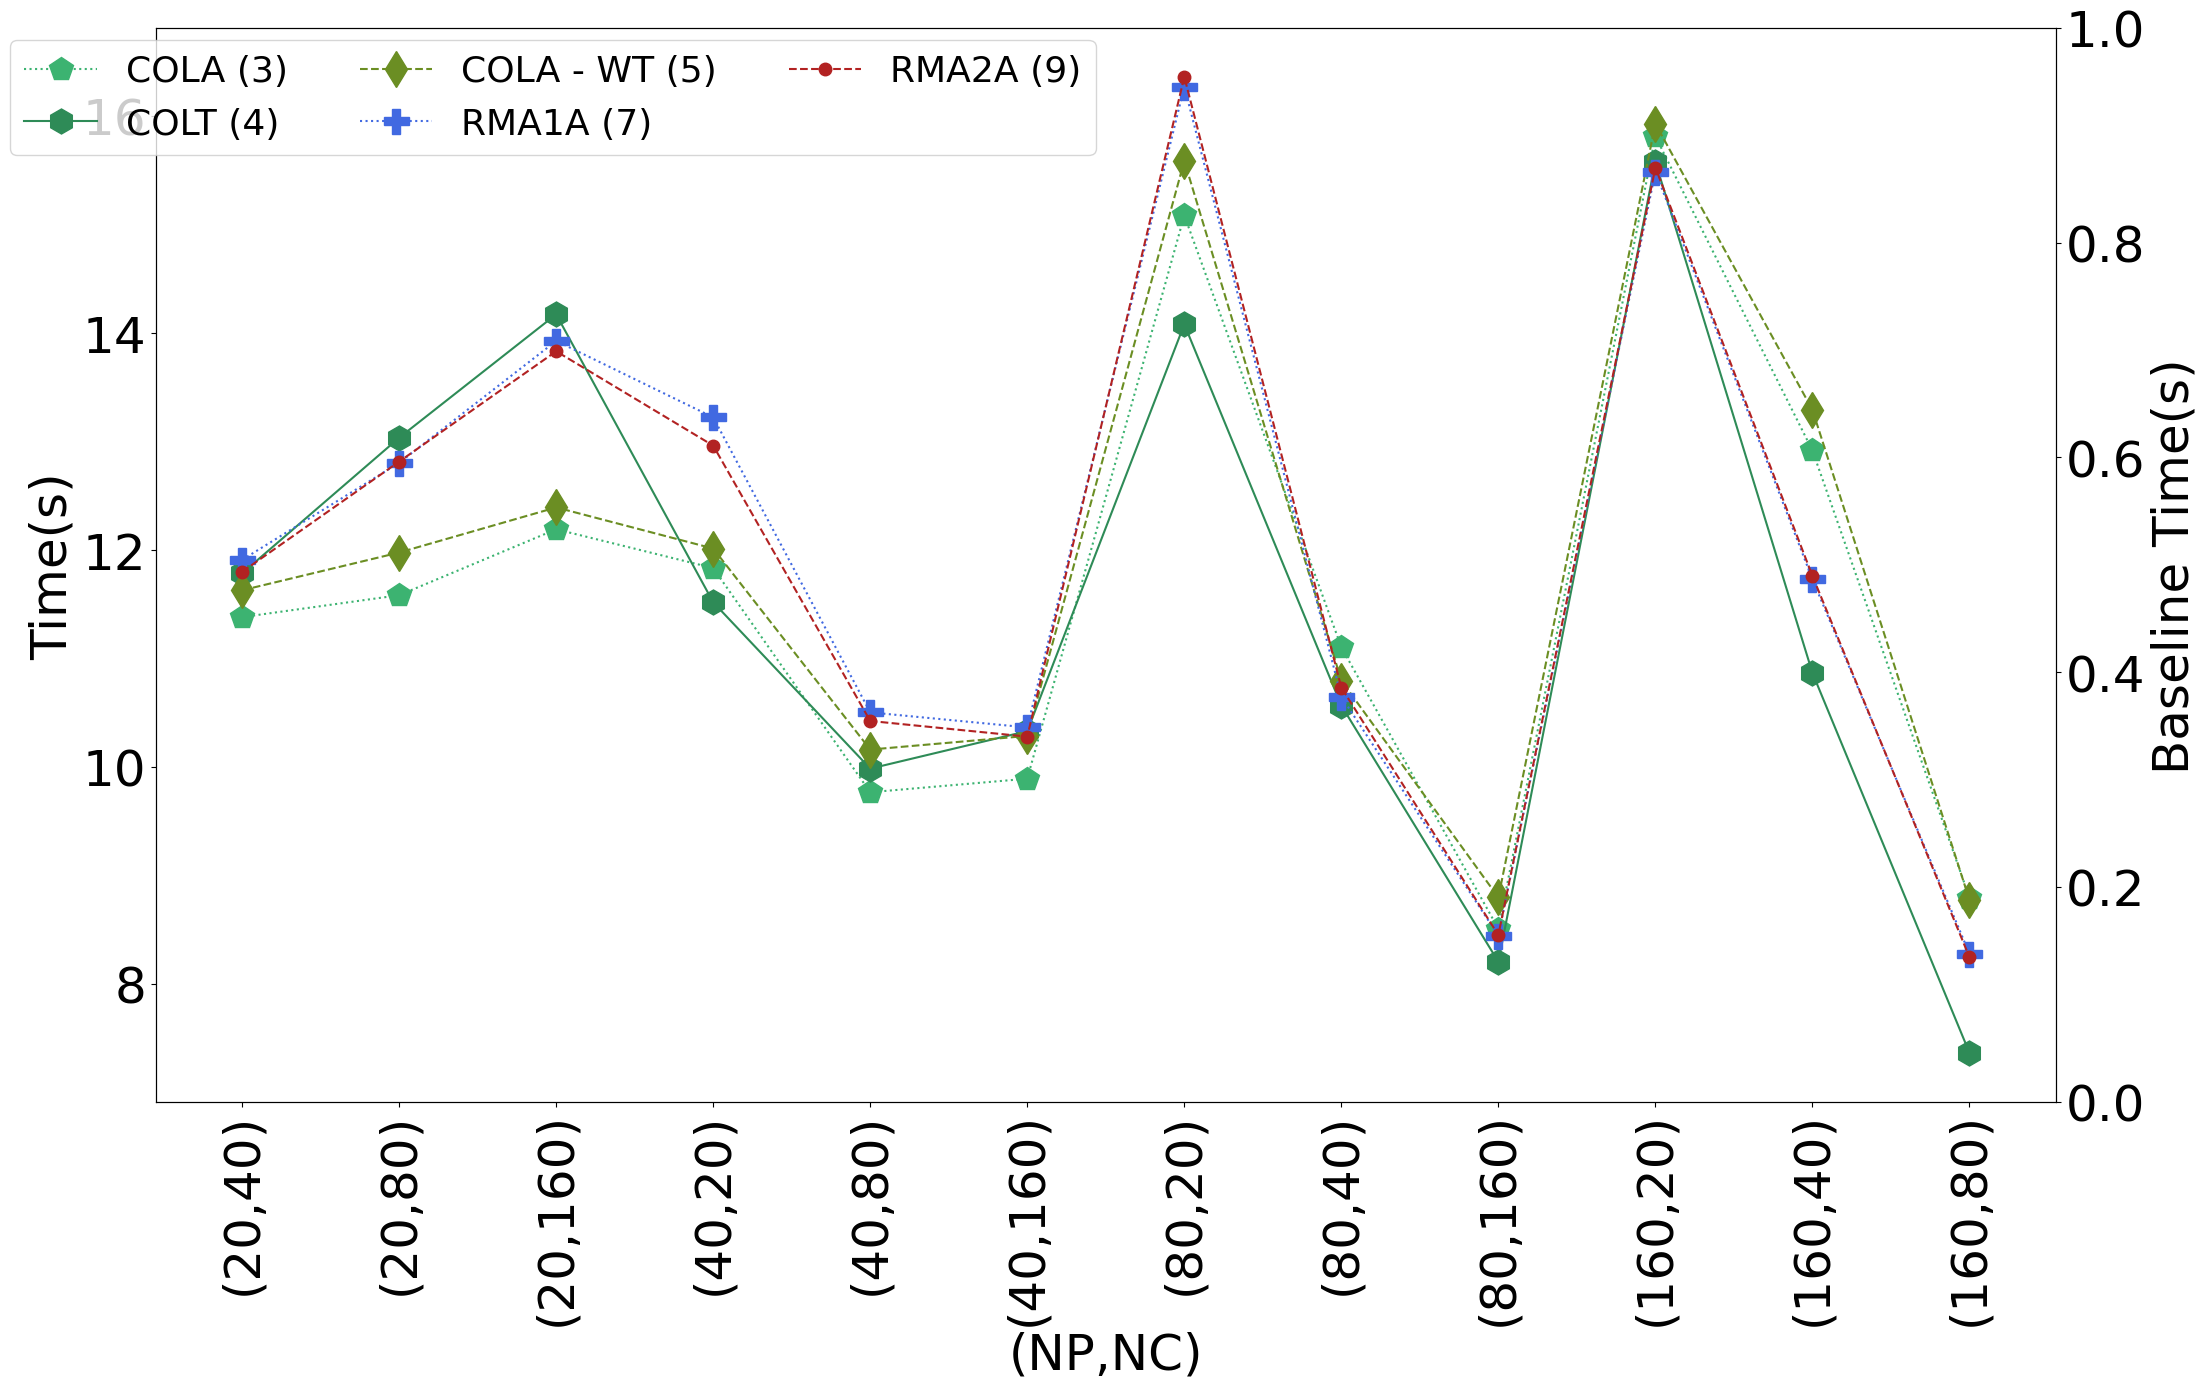

In [88]:
used_direction='a'
test_parameter='T_total'
intranode=False

if test_parameter == 'T_total':
    name_fig="Ttotal"
    real_parameter='T_total'
    name_legend = "Time(s)"
    used_config = configurations
    data_aux = grouped_aggG
    #data_aux = data_aux[data_aux.index.isin(df1.index)]
    
if used_direction=='s':
    data_aux_cmp=grouped_aggM.reset_index().query('NP > NC')
    name_fig= name_fig+"Shrink"
elif used_direction=='e':
    data_aux_cmp=grouped_aggM.reset_index().query('NP < NC')
    name_fig= name_fig+"Expand"
elif used_direction=='a':
    data_aux_cmp=grouped_aggM.reset_index()
    name_fig= name_fig+"All"
    
if intranode:
    data_aux_cmp = data_aux_cmp.query('NP <= 20 and NC <= 20')
#else:
    #data_aux_cmp = data_aux_cmp.query('NP > 20 and NC > 20')
#data_aux_cmp = data_aux_cmp.query('NP == 160 or NC == 160')

if used_direction!='a':
    pruebaG = data_aux.reset_index()
    pruebaG = pruebaG.loc[pruebaG.index.intersection(data_aux_cmp.index)]
    data_aux = data_aux[(data_aux.T_total.isin(pruebaG.T_total))]

plot_data = []
for config in used_config:
    #if config[0] == 0:
    dataLists,procsLists = get_config_data(real_parameter, data_aux, config)
    dataLists = list(filter(lambda x: x != float('infinity'), dataLists))
    plot_data.append(dataLists)

#labels_aux = create_labels_lineplot(used_direction, lambda a, b: a == 160 or b == 160)
labels_aux = create_labels_lineplot(used_direction)
plot_data = reorder_data(plot_data, procsLists, labels_aux)
#plot_data_normalized = normalize_arrays(plot_data[1:], plot_data[0])
#name_legend="SpeedUp over Baseline"

labelsMethods_aux = ['COLS (0)',
                     'RMA1S (1)', 'RMA2S (2)',
                     'COLA (3)', 'COLT (4)',
                     'COLA - WT (5)', 
                     'RMA1T (6)', 'RMA1A (7)',
                     'RMA2T (8)', 'RMA2A (9)']


colors_m = (
    colors.to_rgba("green"), #BCOLS
    colors.to_rgba("blue"),  #BRMA1S
    colors.to_rgba("red"), #MCOLS
    
    colors.to_rgba("mediumseagreen"), #BCOLA
    colors.to_rgba("seagreen"),  #BCOLT
    colors.to_rgba("olivedrab"), #BP2PT
    
    colors.to_rgba("cornflowerblue"),  #BIntraCOLS
    colors.to_rgba("royalblue"), #BIntraP2PS
            
    colors.to_rgba("darkred"),  #MP2PS
    colors.to_rgba("firebrick"), #MCOLT - WS
    )


f=plt.figure(figsize=(22, 14))
ax=f.add_subplot(111)
ax2 = ax.twinx()
x = np.arange(len(labels_aux))
ignore = [0,1,2,6,8]
for index in range(len(plot_data)):
    array_aux = plot_data[index]
    
    if ignore and index in ignore:
        continue
    print(array_aux)
    #index= index+1
    ax.plot(x, array_aux, color=colors_m[index%len(colors_m)], linestyle=linestyle_m[index%len(linestyle_m)], \
        marker=markers_m[index%len(markers_m)], markersize=18, label=labelsMethods_aux[index])
#ax2.plot(x, plot_data[0], color='black', linestyle=linestyle_m[0], \
#        marker=markers_m[0], markersize=18, label=labelsMethods_aux[0])
#ax.axhline(y=1, color='black', linestyle='--')

ax.set_xlabel("(NP,NC)", fontsize=36)
ax.set_ylabel(name_legend, fontsize=36)
ax.tick_params(axis='both', which='both', labelsize=36)
ax.set_xticks(x)
ax.set_xticklabels(labels_aux, rotation=90)
#ax.legend(loc='best', fontsize=30,ncol=2,framealpha=0.8)

ax2.set_ylabel('Baseline Time(s)', fontsize=36)
ax2.tick_params(axis='y', which='both', labelsize=36)
#ax2.legend(loc='best', fontsize=30,ncol=2,framealpha=0.8)

f.legend(bbox_to_anchor=(0.5, 0.98), fontsize=26,ncol=3,framealpha=0.8)

        
f.tight_layout()
f.savefig("Images/LinePlot_"+name_fig+".png", format="png")

In [26]:
def generate_3d_image(config, name):
    fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=(15, 15))

    Z = [None] * len(processes)
    X, Y = np.meshgrid(processes, processes)
    for i in range(len(processes)):
        np_aux = processes[i]
        Z[i] = [0] * len(processes)
        Z[i][i] = grouped_aggLSynch.loc[np_aux, 'T_iter'] * 1000
        for j in range(len(processes)):
            if i!=j:
                ns_aux = processes[j]
                config.append((np_aux,ns_aux))
                aux = grouped_aggG.loc[tuple(config),'T_total']
                config.pop()
            
                Z[i][j] = aux.values[0]
                #Z[i][j] = Z[i][j] / Z[i][i]
        #Z[i][i] = 1

    Z = np.array(Z)

    ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
    ax.view_init(15, 25)
    ax.set_xlabel("NC", fontsize=16)
    ax.set_ylabel("NP", fontsize=16)
    ax.set_zlabel("Normalized time", fontsize=16)
    ax.set_title(name, fontsize=10)
    plt.show()
    
for index in range(len(configurations)):
    used_config = configurations[index]
    generate_3d_image(used_config,str(index))

In [ ]:
test=dfM[(dfM.Asynch_Iters > 0)]

# Seguro con barriers en Malleability
test["Resize_Coherency"] = test["T_Malleability"] >= (test["T_spawn"] + test["T_SR"] + test["T_AR"])
# Seguro al usar Rigid para iteraciones
test["Resize_Coherency2"] = test["T_Malleability"] >= 0

for index in range(len(test)):
    time_malleability_aux = test["T_Malleability"].values[index]
    time_synch_aux = test["T_SR"].values[index]
    time_spawn_aux = test["T_spawn"].values[index]
    is_asynch_spawn = (test["Spawn_Strategy"].values[index] % 2 == 0)
    
    total_asynch_iters = int(test["Asynch_Iters"].values[index])
    asynch_iters = test["T_iter"].values[index][-total_asynch_iters:]
    time_iters_aux = np.sum(asynch_iters[:])
    
    sum_times = time_synch_aux + is_asynch_spawn * time_spawn_aux + time_iters_aux
    
    if time_malleability_aux < sum_times:
        real_index = test.index.values[index]
        test.at[real_index, "Resize_Coherency2"] = False
test[(test.Resize_Coherency == False)].query('Redistribution_Method > 1')

In [ ]:
import dask.dataframe as dd
ddf = dd.from_pandas(dfL[(dfL.Asynch_Iters == False)], npartitions=10)
group = ddf.groupby('NP')['T_iter']
grouped_aggLSynch = group.agg(['mean'])
grouped_aggLSynch = grouped_aggLSynch.rename(columns={'mean':'T_iter'}) 
grouped_aggLSynch = grouped_aggLSynch.compute()

In [ ]:
def test_ecdf(data1, data2):
    diff_aux = data1[0] - data2[0]
    cmp_f = (lambda a, b: a-b < 0) # Se esperan siempre diferencias positivas, si una es negativa se cruzan los ecdf's
    if diff_aux < 0:
        cmp_f = (lambda a, b: a-b > 0) # Se esperan siempre diferencias negativas, si una es positivas se cruzan los ecdf's
        
    for index_value in range(1,len(data1)):
        if cmp_f(data1[index_value], data2[index_value]):
            return False
    return True

def plot_ecdf(data1, data2, ecdf1, ecdf2, title):
    f=plt.figure(figsize=(22, 14))
    ax=f.add_subplot(111)

    ax.plot(data1, ecdf1, color=colors_m[0], linestyle=linestyle_m[0], \
        marker=markers_m[0], markersize=18)
    ax.plot(data2, ecdf2, color=colors_m[2], linestyle=linestyle_m[2], \
        marker=markers_m[2], markersize=18)

    ax.set_xlabel("Values", fontsize=36)
    ax.set_ylabel("Bins", fontsize=36)
    ax.tick_params(axis='both', which='major', labelsize=36)
    ax.tick_params(axis='both', which='minor', labelsize=36)
    ax.set_title(title, fontsize=40)
        
    f.tight_layout()

def check_specific_ecdf(np_aux, ns_aux, configuration_index):
    df_check = dfM
    tipo = 'T_Redistribution'
    used_config = configurations_simple
    dataLists = get_df_np_ns_data(df_check, tipo, used_config, np_aux, ns_aux)
    ecdfLists = []
    for index_i in range(len(dataLists)):
        dataLists[index_i].sort()
        ecdfLists.append( np.arange(1, len(dataLists[index_i])+1)/float(len(dataLists[index_i])) )

    index_i = configuration_index
    data_i = dataLists[index_i]
    ecdf_i = ecdfLists[index_i]
    for index_j in range(len(dataLists)):
        if index_i != index_j:
            data_j = dataLists[index_j]
            ecdf_j = ecdfLists[index_j]
            res_aux = test_ecdf(data_i, data_j)
            if not res_aux:
                aux_title = "NP="+str(np_aux)+"/NC="+str(ns_aux)+" -- Comparing C"+str(index_i) + " vs C"+str(index_j)
                plot_ecdf(data_i, data_j, ecdf_i, ecdf_j, aux_title)

In [ ]:
for np_aux in processes:
    for ns_aux in processes:
        if np_aux != ns_aux and not (np_aux==2 and ns_aux==20):
            check_winner_ecdf(np_aux, ns_aux, 9)

        
        

In [ ]:
a = 5
b = 3
c = False
d = a + b * c
print(d)

In [ ]:
#Ethernet
b1_aux = [82.747868, 83.191989, 95.520019, 87.435987, 90.843995, 150.356100]
b2_aux = [75.238174, 74.380054, 74.755995, 42.656109, 21.588040, 17.843997]
m1_aux = [74.654167, 74.357901, 74.351350, 43.599915, 21.637509, 15.128712]
m2_aux = [74.353249, 74.359214, 74.356160, 43.874266, 21.511082, 14.969010]

b3_aux = [105.128014, 110.004008, 126.552019, 116.312400, 95.752019, 151.023994]
b4_aux = [83.021885, 77.632630, 75.396010, 43.076039, 24.028075, 19.556047]
m3_aux = [118.275992, 83.027866, 81.008479, 46.432212, 24.247949, 17.725083]
m4_aux = [119.286457, 84.205993, 80.741585, 47.144632, 24.206617, 17.738496]

In [ ]:
#Infiniband
b1_aux = [64.669525, 35.171971, 38.916010, 47.456630, 56.288048, 119.428020]
b2_aux = [36.538361, 15.536046, 13.396083, 9.652013, 5.772058, 5.615009]
m1_aux = [61.664380, 18.400559, 19.112526, 22.155880, 11.712381, 30.775627]
m2_aux = [33.428639, 13.905561, 14.691367, 7.363081, 6.629037, 12.150872]

b3_aux = [91.368664, 60.648074, 53.663981, 49.152031, 64.752057, 118.243807]
b4_aux = [84.941260, 34.039990, 26.008021, 12.298989, 7.916004, 5.736054]
m3_aux = [105.839726, 26.822071, 23.834452, 12.876862, 9.063136, 7.007535]
m4_aux = [75.412319, 25.566336, 22.129483, 12.491161, 7.903744, 6.534291]

In [ ]:


plot_data_e = [b1_aux, m1_aux, b2_aux, m2_aux] #Expand
plot_data_s = [b3_aux, m3_aux, b4_aux, m4_aux] #Shrink

labels_aux_e = create_labels_lineplot('e', lambda a, b: a == 160 or b == 160)
labels_aux_s = create_labels_lineplot('s', lambda a, b: a == 160 or b == 160)
#labels_aux = create_labels_lineplot(used_direction)

labelsMethods_aux = ['Baseline - AllS', 'Merge - AllS',
                     'Baseline - AllA','Merge - AllA']

#labelsMethods_aux = ['Baseline - All', 'Baseline - P2P','Merge - All','Merge - P2P']

f, (axe, axs)=plt.subplots(1,2,figsize=(22, 14))
x = np.arange(len(labels_aux_e))
for index in range(len(plot_data_e)):
    array_aux_e = plot_data_e[index]
    array_aux_s = plot_data_s[index]
    plot_index = index
    if index > 0:
        plot_index = 2**plot_index
    print(array_aux_e)
    axe.plot(x, array_aux_e, color=colors_m[plot_index%len(colors_m)], linestyle=linestyle_m[plot_index%len(linestyle_m)], \
        marker=markers_m[plot_index%len(markers_m)], markersize=18, label=labelsMethods_aux[index])
    axs.plot(x, array_aux_s, color=colors_m[plot_index%len(colors_m)], linestyle=linestyle_m[plot_index%len(linestyle_m)], \
        marker=markers_m[plot_index%len(markers_m)], markersize=18, label=labelsMethods_aux[index])

axe.set_xlabel("(NP,NC)", fontsize=36)
axe.set_ylabel("Time(s)", fontsize=36)
axe.set_xticks(x)
axe.set_xticklabels(labels_aux_e, rotation=90)
axe.tick_params(axis='both', which='major', labelsize=36)
axe.tick_params(axis='both', which='minor', labelsize=36)

axs.set_xlabel("(NP,NC)", fontsize=36)
axs.set_ylabel("Time(s)", fontsize=36)
axs.set_xticks(x)
axs.set_xticklabels(labels_aux_s, rotation=90)
axs.tick_params(axis='both', which='major', labelsize=36)
axs.tick_params(axis='both', which='minor', labelsize=36)

plt.legend(loc='best', fontsize=30,ncol=2,framealpha=0.8)
        
f.tight_layout()
f.savefig("Images/LinePlot_100Gb.png", format="png")

In [ ]:
%matplotlib inline
import pandas as pd
from pandas import DataFrame, Series
import numpy as np


new_df = pd.read_pickle( "dataBasic.pkl" )
new_df.columns

In [ ]:
grouped_aggG["T_total"]

In [ ]:
100000 ** 2